In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir('..')
import functions.myfunctions as mf
import tidytcells as tt

In [ ]:
f2 = 'data/output/figures/'

In [3]:
vdj = pd.read_csv('data/vdj_cleaned_subset_for_MI_no-small-study.csv', index_col = 0)
print(vdj.head())
print(vdj.shape)

   Unnamed: 0  complex.id Gene-a           CDR3-a       V-a     J-a  \
0          13          14    TRA    CAYTVLGNEKLTF  TRAV38-1  TRAJ48   
1          14          15    TRA  CAVAGYGGSQGNLIF  TRAV12-2  TRAJ42   
2          15          16    TRA     CAVSFGNEKLTF  TRAV12-2  TRAJ48   
3          16          17    TRA  CAVTHYGGSQGNLIF  TRAV12-2  TRAJ42   
4          17          18    TRA    CAGGGGGADGLTF  TRAV12-2  TRAJ45   

       Species     MHC A MHC B MHC class  ... cdr2a_IMGTgaps cdr2b_IMGTgaps  \
0  HomoSapiens  HLA-A*02   B2M      MHCI  ...     QEAY--KQQN     SYD----VKM   
1  HomoSapiens  HLA-A*02   B2M      MHCI  ...     IYS----NGD     SYD----VKM   
2  HomoSapiens  HLA-A*02   B2M      MHCI  ...     IYS----NGD     SYD----VKM   
3  HomoSapiens  HLA-A*02   B2M      MHCI  ...     IYS----NGD     SYD----VKM   
4  HomoSapiens  HLA-A*02   B2M      MHCI  ...     IYS----NGD     SYD----VKM   

    cdr3a_IMGTgaps   cdr3b_IMGTgaps len_cdr3a len_cdr3b len_cdr3a_IMGTgaps  \
0  CAYTVLG--NEKLTF  

In [4]:
estimatedMI = pd.read_csv('data/output/mutual_info/estimated_mutual_info_all_epitopes_w_studyspecific_shuffle_wdupl.csv')

In [5]:
estimatedMI.head()

,Unnamed: 0,real,shuffle
0,ASNENMETM_Ja-CDR3a,15.700707,6.661307
1,ASNENMETM_Ja-CDR3b,8.410085,5.266553
2,ASNENMETM_Ja-Jb,0.838501,0.540358
3,ASNENMETM_Jb-CDR3a,4.095908,2.620880
4,ASNENMETM_Jb-CDR3b,9.929622,2.113542


Plot cute heatmaps with summary of all data

In [6]:
estimatedMI.columns = ['name', 'real', 'shuffle']

estimatedMI[['epitope', 'vars']] = estimatedMI['name'].str.split(pat = '_', n = 1, expand=True)
estimatedMI[['var1','var2']] = estimatedMI['vars'].str.split(pat = '-', n = 1, expand=True)
estimatedMI = estimatedMI.drop(['name','vars'], axis=1)
estimatedMI['real_MI'] = estimatedMI['real'] - estimatedMI['shuffle']
estimatedMI['var1'] = estimatedMI['var1'].replace('cdr3a','CDR3a')
estimatedMI['var2'] = estimatedMI['var2'].replace('cdr3a','CDR3a')
estimatedMI['var1'] = estimatedMI['var1'].replace('cdr3b','CDR3b')
estimatedMI['var2'] = estimatedMI['var2'].replace('cdr3b','CDR3b')
print(estimatedMI)

          real    shuffle     epitope   var1   var2   real_MI
0    15.700707   6.661307   ASNENMETM     Ja  CDR3a  9.039400
1     8.410085   5.266553   ASNENMETM     Ja  CDR3b  3.143532
2     0.838501   0.540358   ASNENMETM     Ja     Jb  0.298142
3     4.095908   2.620880   ASNENMETM     Jb  CDR3a  1.475028
4     9.929622   2.113542   ASNENMETM     Jb  CDR3b  7.816080
..         ...        ...         ...    ...    ...       ...
355   5.329278   4.466636  background     Vb  CDR3a  0.862643
356   7.339870   4.361322  background     Vb  CDR3b  2.978547
357   1.086592   0.900223  background     Vb     Ja  0.186369
358   0.477628   0.353073  background     Vb     Jb  0.124555
359  22.553455  19.697879  background  CDR3a  CDR3b  2.855576

[360 rows x 6 columns]


In [7]:
estimatedMI.head()

,real,shuffle,epitope,var1,var2,real_MI
0,15.700707,6.661307,ASNENMETM,Ja,CDR3a,9.039400
1,8.410085,5.266553,ASNENMETM,Ja,CDR3b,3.143532
2,0.838501,0.540358,ASNENMETM,Ja,Jb,0.298142
3,4.095908,2.620880,ASNENMETM,Jb,CDR3a,1.475028
4,9.929622,2.113542,ASNENMETM,Jb,CDR3b,7.816080


In [8]:
corrected_matrices = {}
cols = ['Va', 'Ja', 'CDR3a', 'Vb', 'Jb', 'CDR3b']

for ep in vdj['Epitope'].unique().tolist() + ['background', 'Tanno::A1::naive']:
    df = pd.DataFrame(index=cols, columns=cols)
    ss = estimatedMI.loc[estimatedMI['epitope'] == ep]
    for i in range(ss.shape[0]):
        row = ss.iloc[i]
        df.at[row['var1'], row['var2']] = row['real_MI']
        df.at[row['var2'], row['var1']] = row['real_MI']

    # df[df < 0] = 0
    print(ep)
    print(df)
    corrected_matrices[ep] = df
    # print(df)
    

ELAGIGILTV
             Va        Ja     CDR3a        Vb        Jb     CDR3b
Va          NaN  0.051131  1.484372   0.01901  0.019078    0.4316
Ja     0.051131       NaN  7.156743  0.031672  0.024647  0.029488
CDR3a  1.484372  7.156743       NaN  0.324602  0.139307  1.379637
Vb      0.01901  0.031672  0.324602       NaN  0.013244  1.518538
Jb     0.019078  0.024647  0.139307  0.013244       NaN  5.627521
CDR3b    0.4316  0.029488  1.379637  1.518538  5.627521       NaN
GILGFVFTL
             Va        Ja     CDR3a        Vb        Jb     CDR3b
Va          NaN  0.533573  5.426634  0.048168  0.187634  1.041621
Ja     0.533573       NaN  9.142713  0.147443  0.135242  1.326598
CDR3a  5.426634  9.142713       NaN  0.599572  1.028391  7.639425
Vb     0.048168  0.147443  0.599572       NaN  0.090638  2.898515
Jb     0.187634  0.135242  1.028391  0.090638       NaN  6.027373
CDR3b  1.041621  1.326598  7.639425  2.898515  6.027373       NaN
NLVPMVATV
             Va        Ja     CDR3a        Vb

In [ ]:
# print out all raw values

xxs = []

for ep in sorted(vdj['Epitope'].unique().tolist())+ ['Tanno::A1::naive', 'background']:
    X = corrected_matrices[ep]
    # print(X)
    mask = np.ones(X.shape,dtype='bool')
    mask[np.tril_indices(X.shape[0])] = False
    # print(mask)
    # print(X.mask(mask))

    xx = pd.DataFrame(X.mask(mask).stack(), columns=[ep])
    xxs.append(xx)

summary_df_raw = pd.concat(xxs, axis=1)
summary_df_raw = summary_df_raw.apply(pd.to_numeric, errors='coerce')

In [10]:
X0 = corrected_matrices['background'].copy()
# X0 = X0.astype('float64')

corrected_matrices_FC = {x:corrected_matrices[x] / X0.astype('float64') for x in corrected_matrices}
print(corrected_matrices_FC['background'])

        Va   Ja CDR3a   Vb   Jb CDR3b
Va     NaN  1.0   1.0  1.0  1.0   1.0
Ja     1.0  NaN   1.0  1.0  1.0   1.0
CDR3a  1.0  1.0   NaN  1.0  1.0   1.0
Vb     1.0  1.0   1.0  NaN  1.0   1.0
Jb     1.0  1.0   1.0  1.0  NaN   1.0
CDR3b  1.0  1.0   1.0  1.0  1.0   NaN


8.272059447044608
ASNENMETM 7.195838126579721
ATDALMTGF 7.253990164960575
AVFDRKSDAK 1.0300735158639966
CINGVCWTV 3.291772678304118
ELAGIGILTV 0.9594803959867223
GILGFVFTL 4.76487574934703
GLCTLVAML 7.47061732542845
HGIRNASFI 7.36625338564883
IVTDFSVIK 2.7432760975001695
KSKRTPMGF 8.272059447044608
LLWNGPMAV 2.214601882215515
LSLRNPILV 3.8286888583678733
LTDEMIAQY 2.59113104272559
NLVPMVATV 3.39510007005012
RAKFKQLL 3.002010389534472
RLRAEAQVK 0.990942430317236
SPRWYFYYL 2.169200486622208
SSLENFRAYV 4.8510241142360595
SSPPMFRV 7.115519261214276
SSYRRPVGI 2.687513267008772
TTDPSFLGRY 1.6852457386414121
YLQPRTFLL 7.609353694511857
Tanno::A1::naive 1.0101841491623094


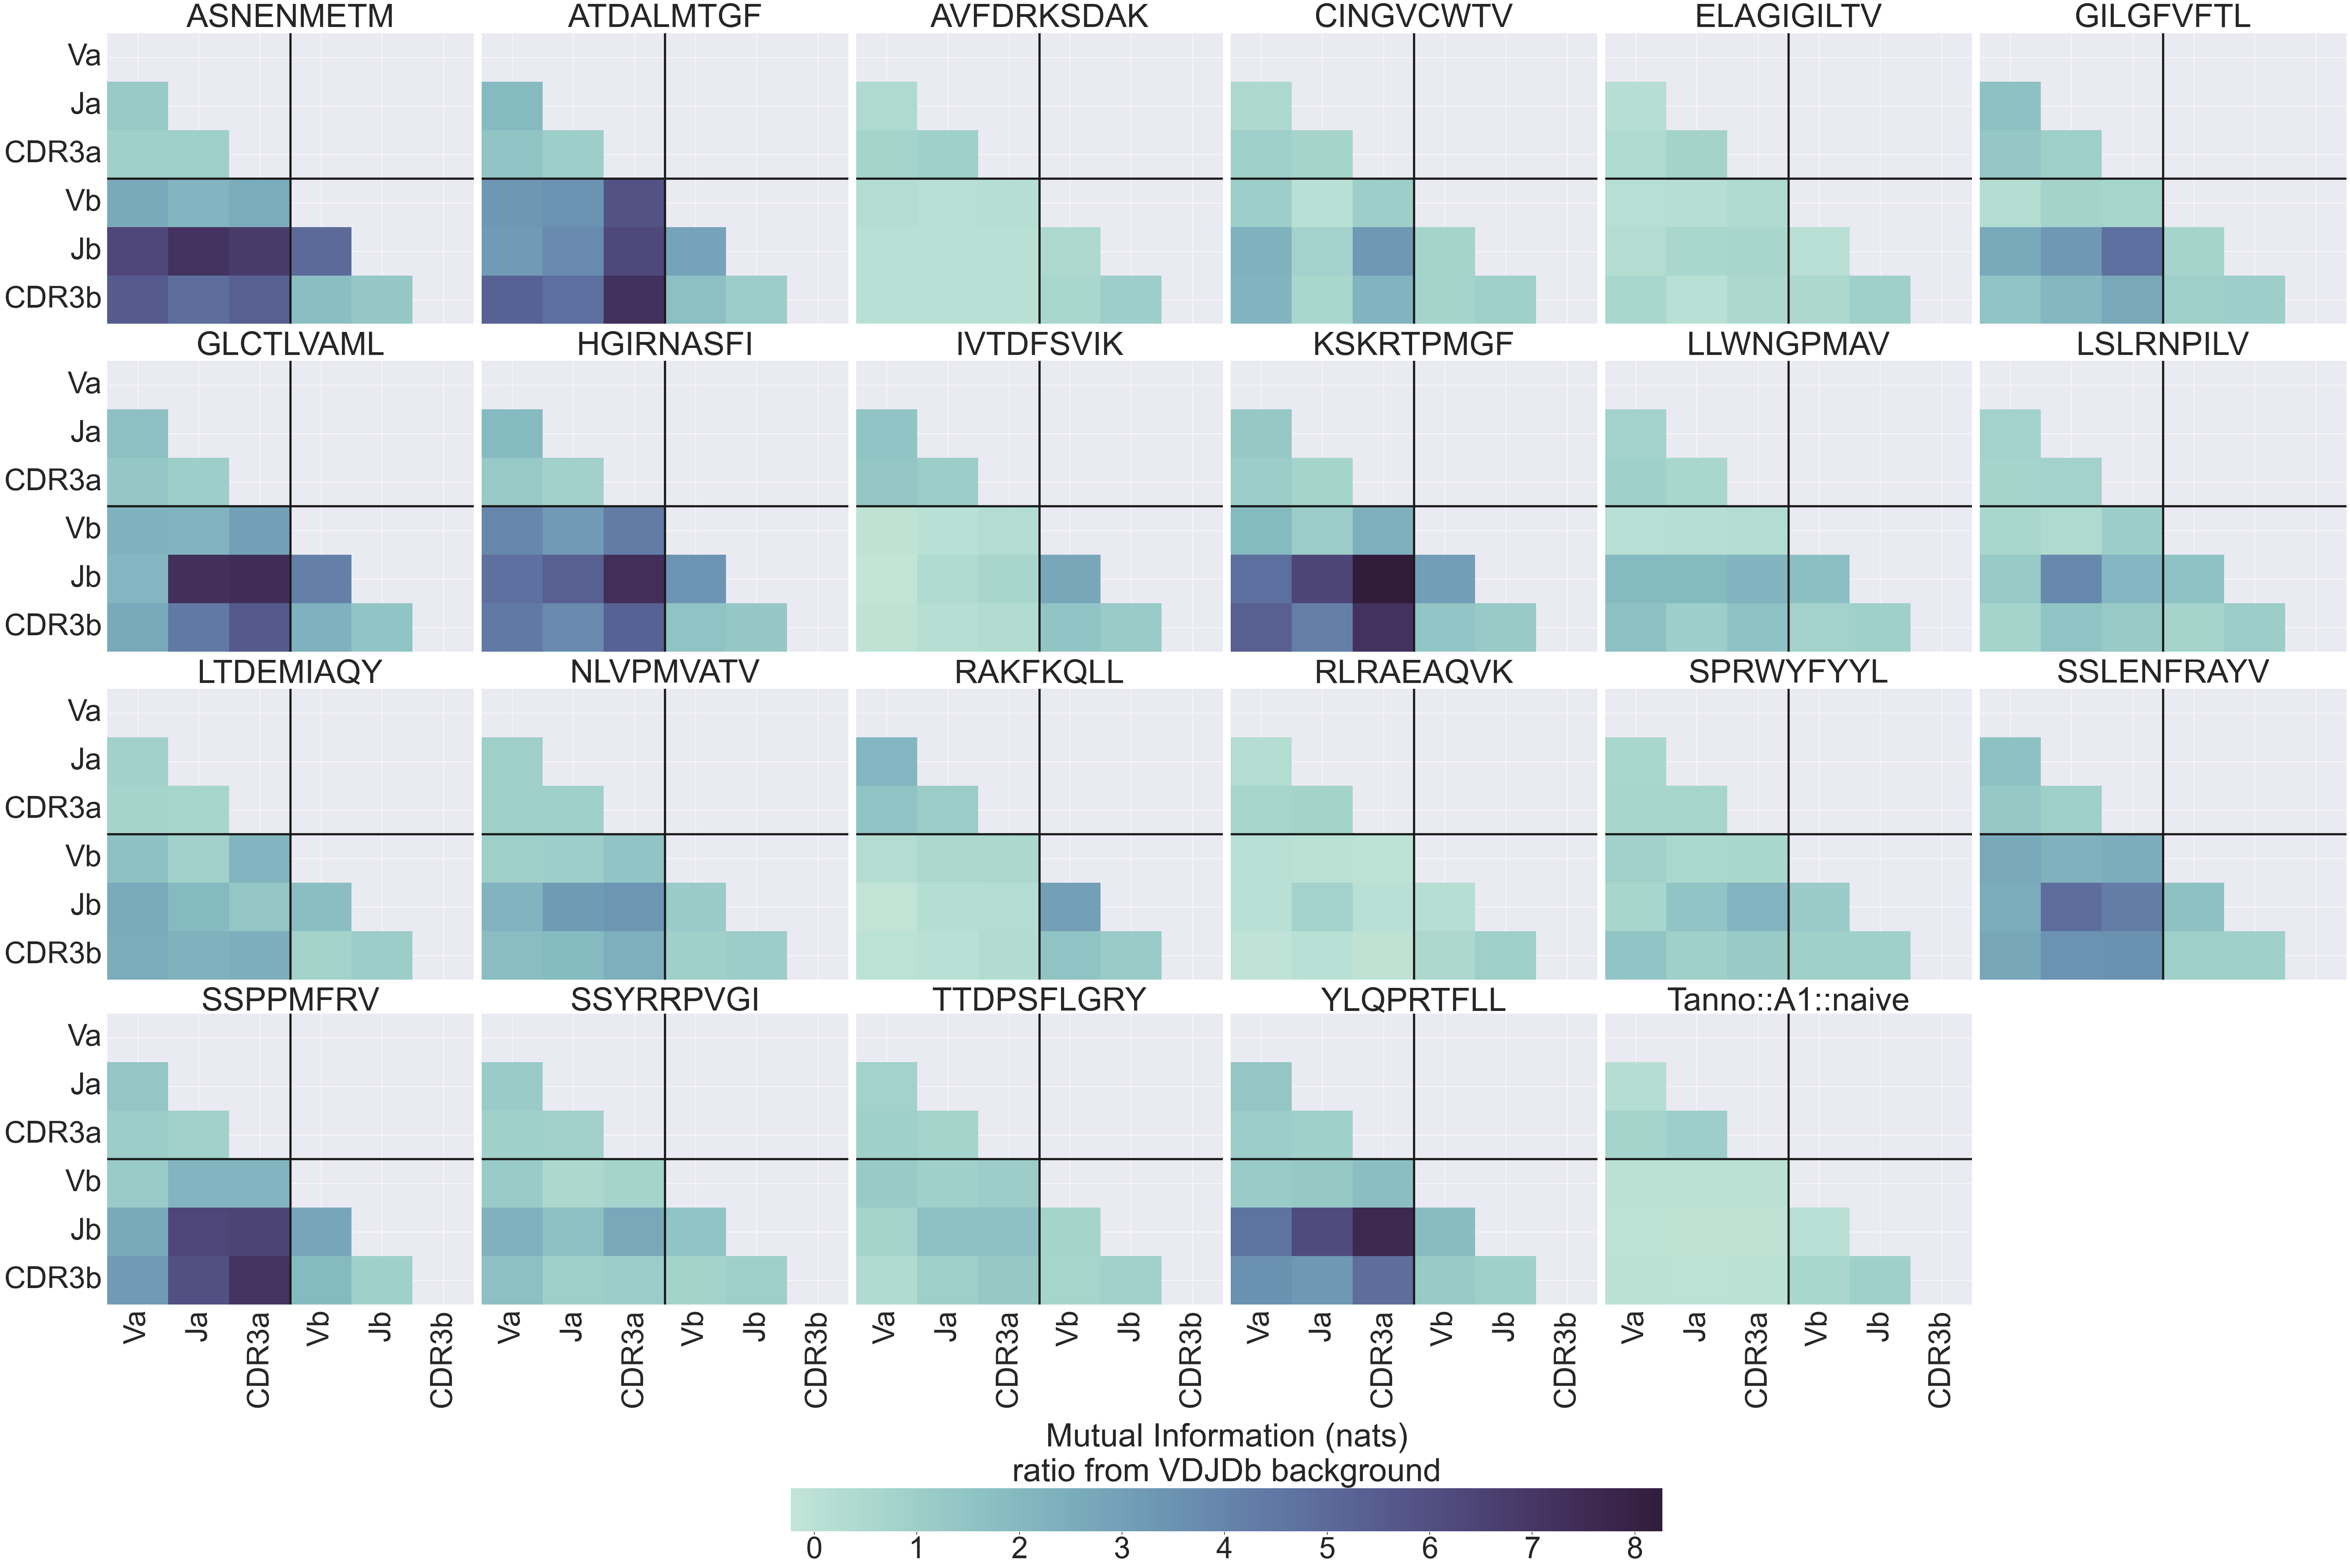

In [11]:
p = sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)
sns.set(font_scale=5)
f, axs = plt.subplots(figsize=(60,40), ncols=6, nrows=4, sharex = True, sharey=True, constrained_layout=True)
ax = axs.ravel()

vmax = np.nanmax([np.nanmax(corrected_matrices_FC[x]) for x in corrected_matrices_FC])
vmin = np.nanmin([np.nanmin(corrected_matrices_FC[x]) for x in corrected_matrices_FC])
print(vmax)
for x, k in enumerate(sorted(vdj['Epitope'].unique().tolist())+ ['Tanno::A1::naive']):
    X = corrected_matrices_FC[k].astype('float64')

    print(k, np.nanmax(X))
    matrix = np.triu(X)

    m=sns.heatmap(X, mask=matrix,
                    cmap = p, ax = ax[x], cbar=False, vmin=vmin, vmax=vmax)
    ax[x].set_title(k)
    ax[x].axhline(3, c='k', ls='-', lw=4)
    ax[x].axvline(3, c='k', ls='-', lw=4)

f.delaxes(ax[-1])
cbar = f.colorbar(m.get_children()[0], ax=axs[-1,:], orientation="horizontal")
cbar.ax.set_title('Mutual Information (nats)\nratio from VDJDb background')
plt.savefig(f2 + 'MutualInformation_all_FC_w_studyspecific_shuffle_wdupl.png')
plt.show()


In [12]:
# try and make a summary plot

xxs = []

for ep in sorted(vdj['Epitope'].unique().tolist())+ ['Tanno::A1::naive']:
    X = corrected_matrices_FC[ep]
    print(X)
    mask = np.ones(X.shape,dtype='bool')
    mask[np.tril_indices(X.shape[0])] = False
    print(mask)
    print(X.mask(mask))

    xx = pd.DataFrame(X.mask(mask).stack(), columns=[ep])
    xxs.append(xx)

summary_df = pd.concat(xxs, axis=1)
print(summary_df)

             Va        Ja     CDR3a        Vb        Jb     CDR3b
Va          NaN  1.255996  0.922549  2.655195  6.329963  5.568365
Ja     1.255996       NaN  0.981438  2.187565  7.195838  4.876479
CDR3a  0.922549  0.981438       NaN  2.557529  6.834289  5.351051
Vb     2.655195  2.187565  2.557529       NaN  4.961962  1.793552
Jb     6.329963  7.195838  6.834289  4.961962       NaN  1.332625
CDR3b  5.568365  4.876479  5.351051  1.793552  1.332625       NaN
[[False  True  True  True  True  True]
 [False False  True  True  True  True]
 [False False False  True  True  True]
 [False False False False  True  True]
 [False False False False False  True]
 [False False False False False False]]
             Va        Ja     CDR3a        Vb        Jb CDR3b
Va          NaN       NaN       NaN       NaN       NaN   NaN
Ja     1.255996       NaN       NaN       NaN       NaN   NaN
CDR3a  0.922549  0.981438       NaN       NaN       NaN   NaN
Vb     2.655195  2.187565  2.557529       NaN       NaN

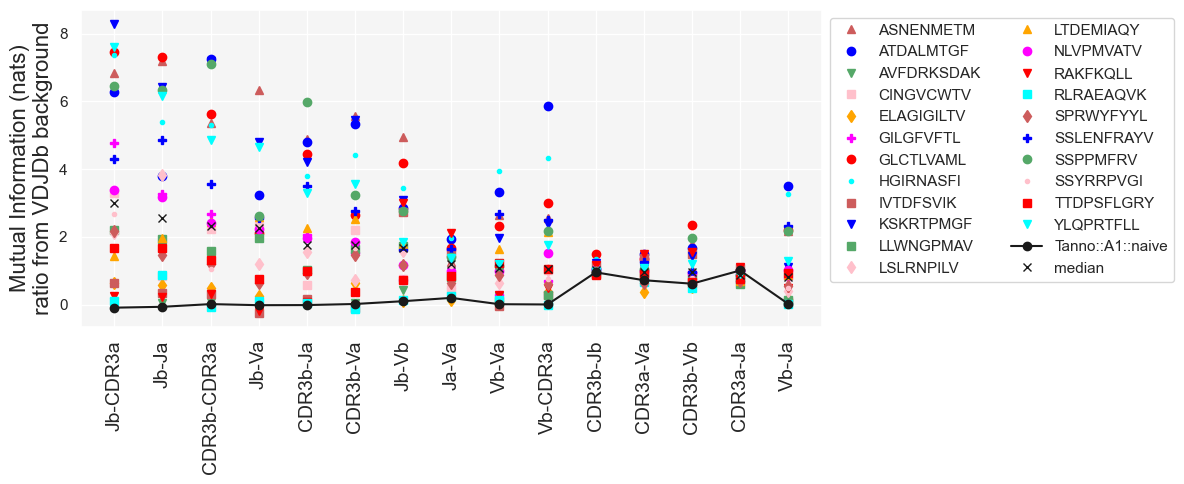

In [13]:
sns.set(font_scale=1)
styles = ['^', 'o', 'v', 's', 'd', 'P','o','.','s','v', 's', 'd','^', 'o', 'v', 's', 'd', 'P','o','.','s','v','o-','x']
colors = ['indianred','blue','g','pink','orange','fuchsia','red','cyan',
          'indianred','blue','g','pink','orange','fuchsia','red','cyan',
          'indianred','blue','g','pink', 'red','cyan','k','k']
f, ax = plt.subplots(figsize=(12,5))
summary_df['median'] = summary_df[vdj['Epitope'].unique().tolist()].median(axis=1)
S = summary_df.sort_values(by='median', ascending=False)
P = S.plot(kind='line', style=styles, color=colors, ax=ax)
ax.set_xticks(list(range(0,len(S.index))))
ax.set_xticklabels(labels=['-'.join(x) for x in S.index], rotation=90, fontdict={'size':14})
plt.legend(bbox_to_anchor = [1,1], ncols=2, loc='upper left', facecolor = 'white')
P.set_facecolor("whitesmoke")
ax.set_ylabel('Mutual Information (nats)\nratio from VDJDb background', fontsize=16)
plt.tight_layout()
plt.savefig(f2 + 'MutualInformation_all_summary_FC_w_studyspecific_shuffle_wdupl.png')
plt.show()

1.3397755154265145
0.8311459321654429
1.3397755154265145


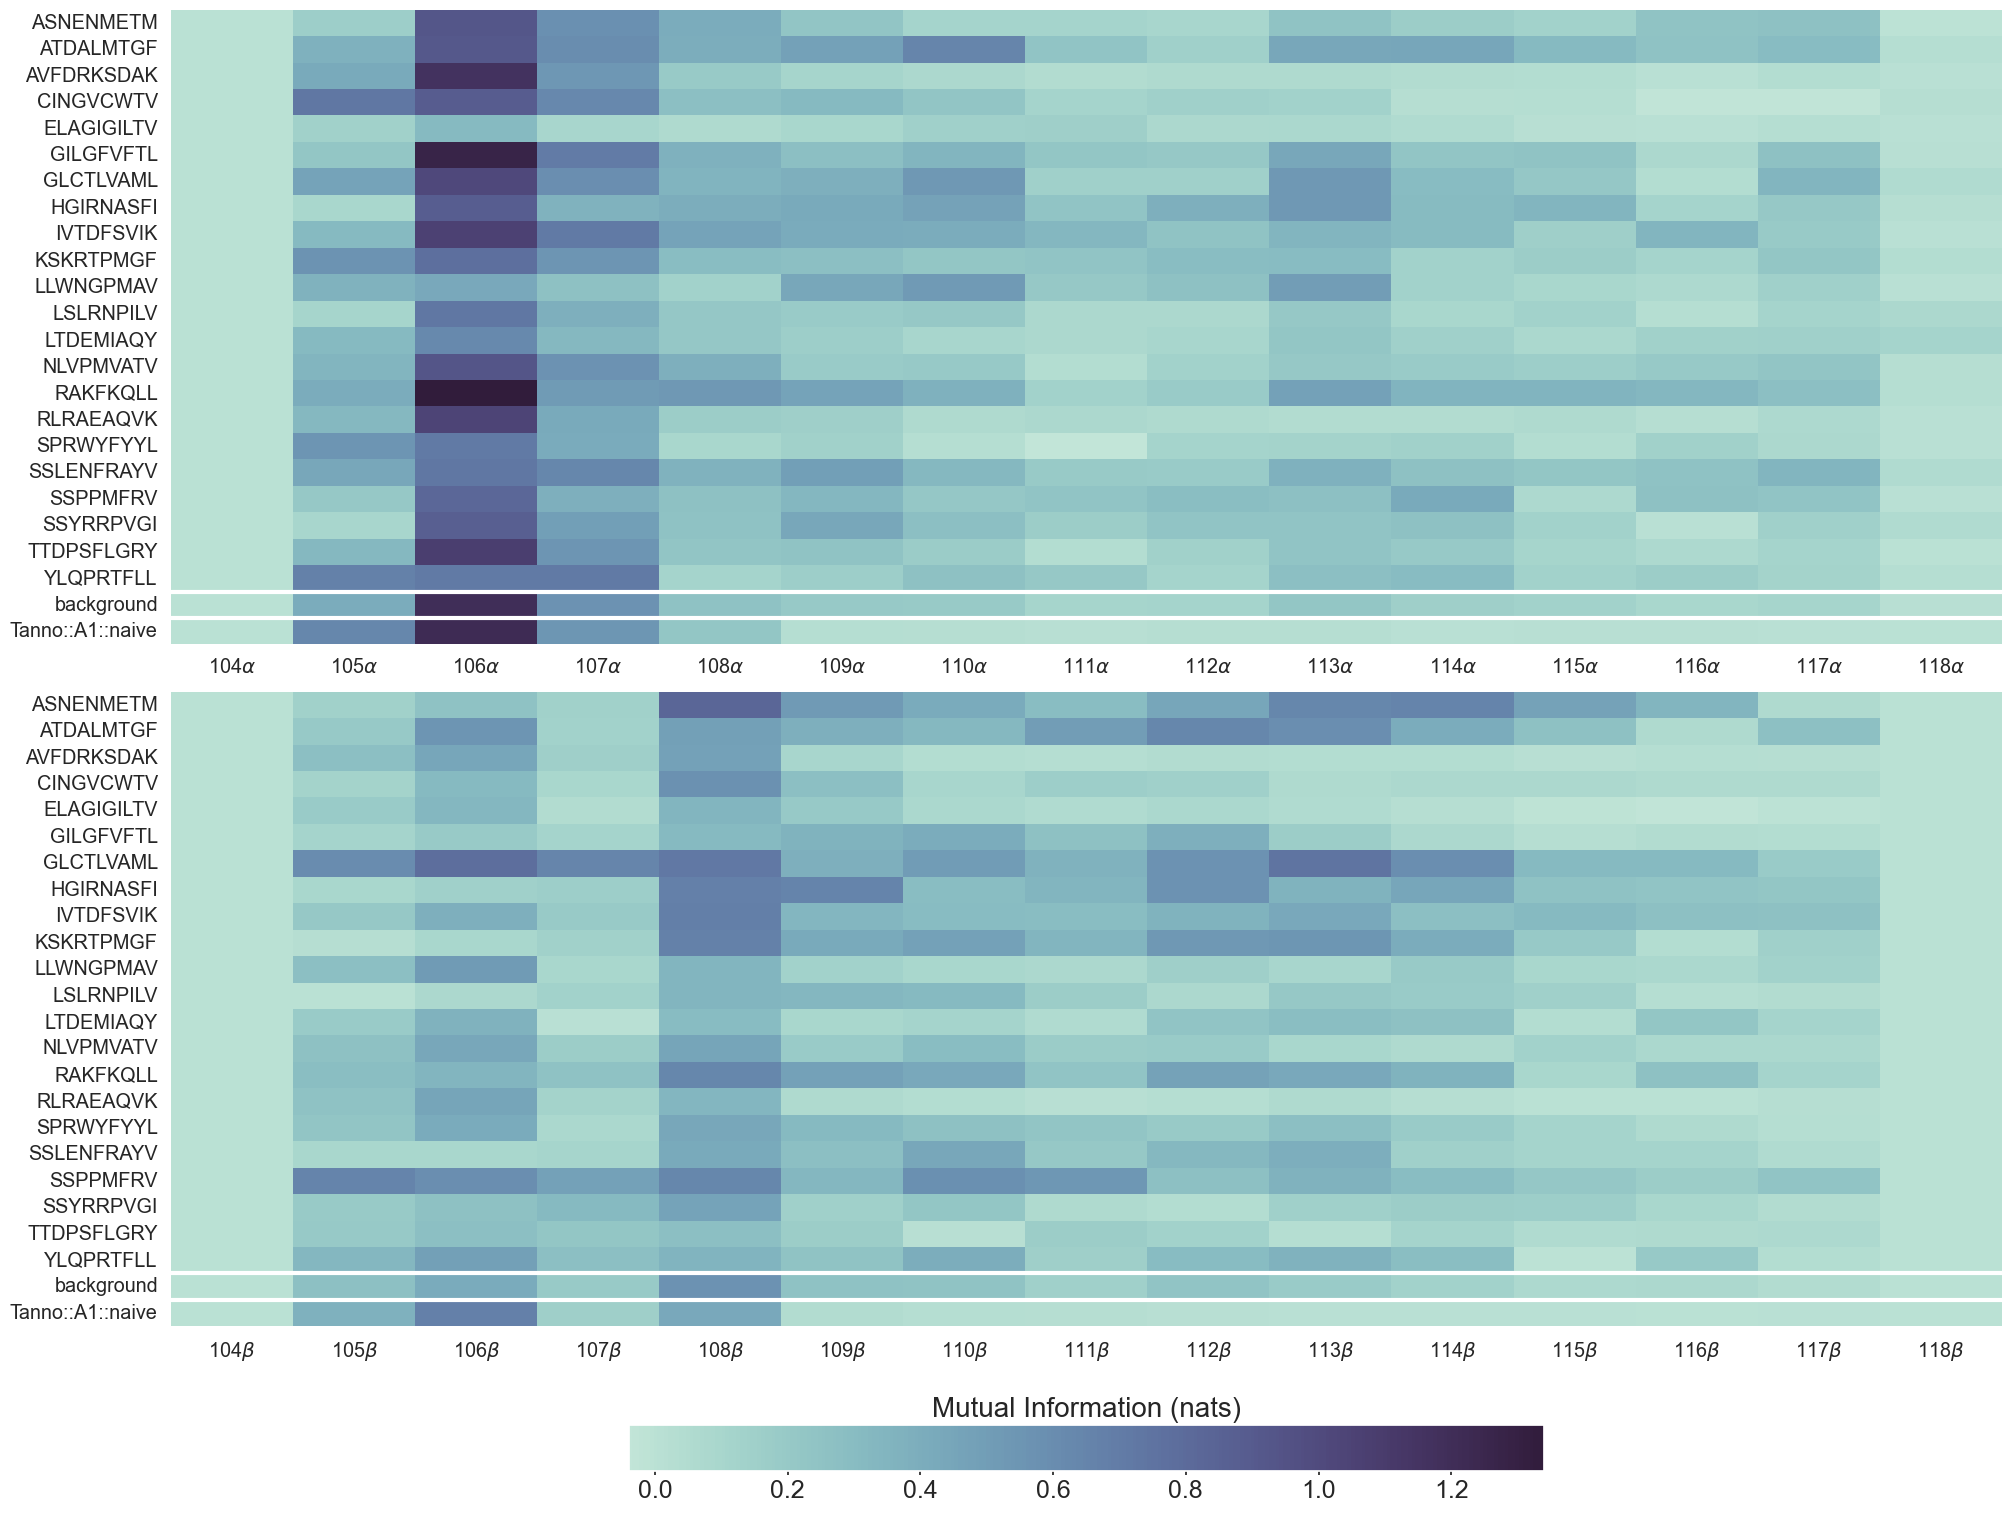

6.864556826212817


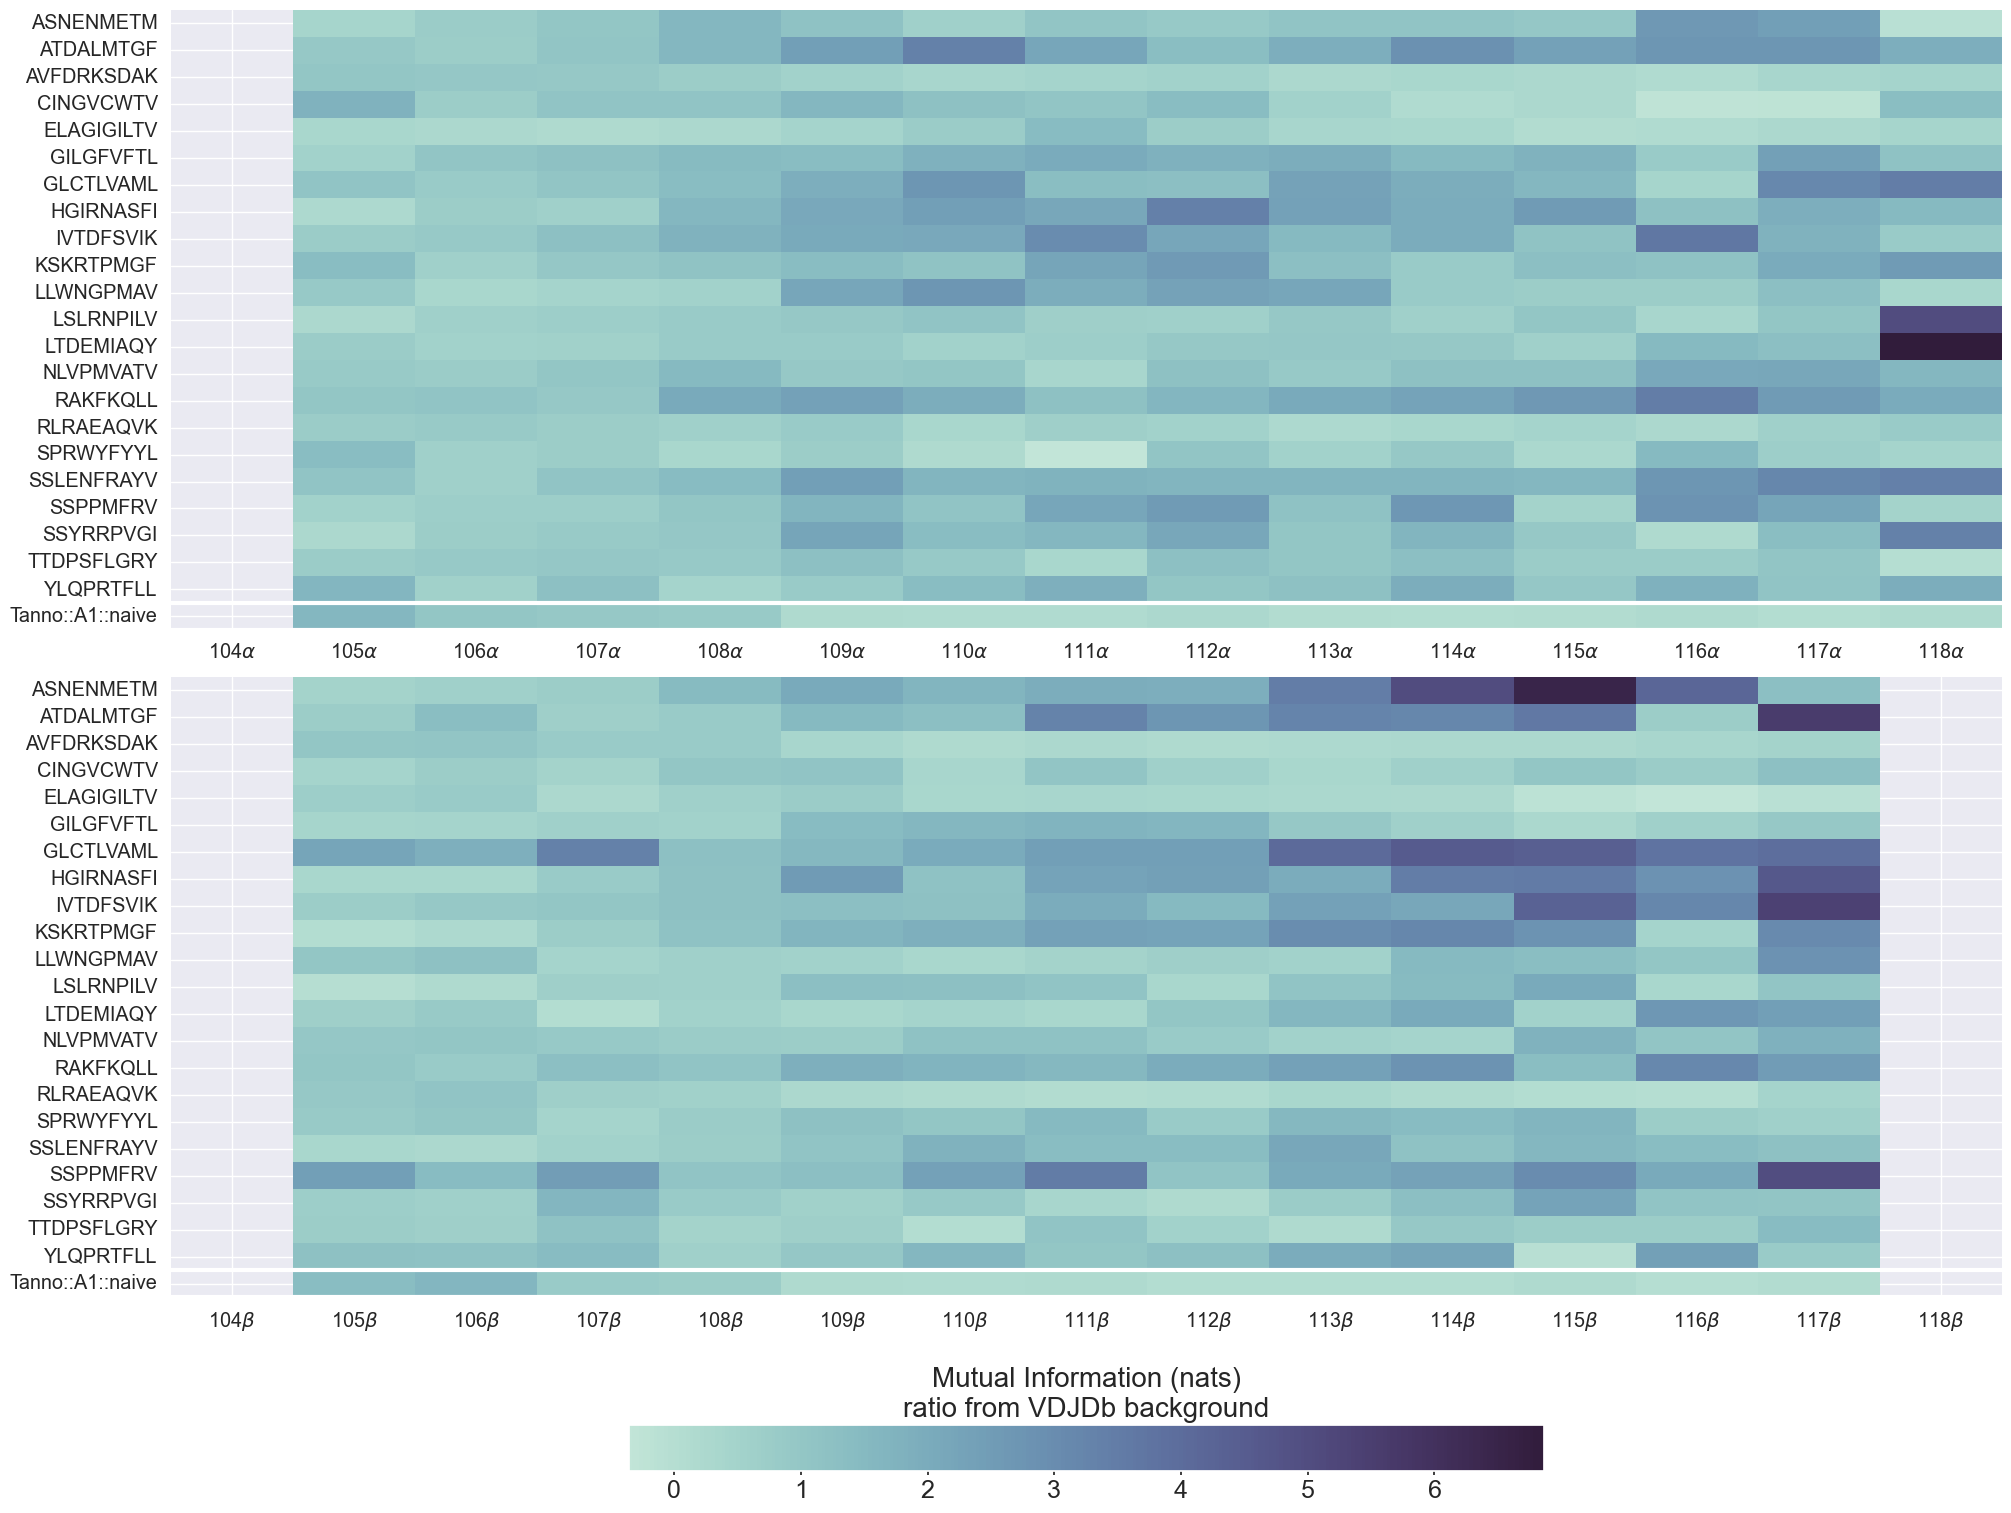

In [14]:
cdr3_res = [104,105,106,107,108,109,110,111,'111.1','111.2','112.2','112.1',112,113,114,115,116,117,118]

all_mi = pd.read_csv('data/output/mutual_info/estimated_mutual_info_all_epitopes_VJ_to_CDR3_by_pos_all_epitopes_w_studyspecific_shuffle_wdupl.csv', index_col=0)

epitopes_a0 = all_mi.loc[all_mi['pair'] == 'Va-CDR3a']
epitopes_a = pd.DataFrame()
for ep in epitopes_a0['epitope'].unique():
    epdf = epitopes_a0.loc[epitopes_a0['epitope'] == ep]
    diff = epdf.loc[epdf['type'] == 'real'][[c for c in epdf.columns if c not in ['epitope', 'type','pair']]].values - epdf.loc[epdf['type'] == 'shuffle'][[c for c in epdf.columns if c not in ['epitope', 'type','pair']]].values
    diff = pd.DataFrame(diff, index=[ep])
    diff['epitope'] = ep
    epitopes_a = pd.concat([epitopes_a, diff])

epitopes_a = epitopes_a.drop('epitope', axis=1)
epitopes_a.columns = [str(x) + r'$\alpha$' for x in cdr3_res]
epitopes_a = epitopes_a.drop([r'112.1$\alpha$', r'111.1$\alpha$', r'112.2$\alpha$', r'111.2$\alpha$'], axis=1)

epitopes_b0 = all_mi.loc[all_mi['pair'] == 'Vb-CDR3b']
epitopes_b = pd.DataFrame()
for ep in epitopes_b0['epitope'].unique():
    epdf = epitopes_b0.loc[epitopes_b0['epitope'] == ep]
    diff = epdf.loc[epdf['type'] == 'real'][[c for c in epdf.columns if c not in ['epitope', 'type','pair']]].values - epdf.loc[epdf['type'] == 'shuffle'][[c for c in epdf.columns if c not in ['epitope', 'type','pair']]].values
    diff = pd.DataFrame(diff, index = [ep])
    diff['epitope'] = ep
    epitopes_b = pd.concat([epitopes_b, diff])
epitopes_b = epitopes_b.drop('epitope', axis=1)
epitopes_b.columns = [str(x) + r'$\beta$' for x in cdr3_res]
epitopes_b = epitopes_b.drop([r'112.1$\beta$', r'111.1$\beta$', r'112.2$\beta$', r'111.2$\beta$'], axis=1)
print(np.nanmax(epitopes_a.values))
print(np.nanmax(epitopes_b.values))

sns.set()
sns.set(font_scale=1.3)
f, axs = plt.subplots(nrows=2, figsize = (20,15), constrained_layout=True)

a = epitopes_a.copy()
b = epitopes_b.copy()
vmax = np.nanmax([np.nanmax(a.values), np.nanmax(b.values)])
vmin = np.nanmin([np.nanmin(a.values), np.nanmin(b.values)])
print(vmax)

sns.heatmap(a.loc[sorted(vdj['Epitope'].unique().tolist())+ ['background', 'Tanno::A1::naive']],
            cmap = p, ax = axs[0], cbar=False, vmin=vmin, vmax=vmax)
m = sns.heatmap(b.loc[sorted(vdj['Epitope'].unique().tolist())+ ['background', 'Tanno::A1::naive']],
                        cmap = p, ax = axs[1], cbar=False, vmin=vmin, vmax=vmax)
axs[0].axhline(22, c='white', ls='-', lw=3)
axs[0].axhline(23, c='white', ls='-', lw=3)
axs[1].axhline(22, c='white', ls='-', lw=3)
axs[1].axhline(23, c='white', ls='-', lw=3)
cbar = f.colorbar(m.get_children()[0], ax=axs[-1], orientation="horizontal", shrink=0.5)
cbar.ax.tick_params(labelsize=18, size=3)
cbar.ax.set_title('Mutual Information (nats)', fontsize=20)
plt.savefig(f2 + 'MutualInformation_V_cdr3aa_w_studyspecific_shuffle_wdupl.png')
plt.show()

sns.set()
sns.set(font_scale=1.3)
f, axs = plt.subplots(nrows=2, figsize = (20,15), constrained_layout=True)

a = epitopes_a/epitopes_a.loc['background']
b = epitopes_b/epitopes_b.loc['background']
vmax = np.nanmax([np.nanmax(a.values), np.nanmax(b.values)])
vmin = np.nanmin([np.nanmin(a.values), np.nanmin(b.values)])
print(vmax)

sns.heatmap(a.loc[sorted(vdj['Epitope'].unique().tolist())+ ['Tanno::A1::naive']],
            cmap = p, ax = axs[0], cbar=False, vmin=vmin, vmax=vmax)
m = sns.heatmap(b.loc[sorted(vdj['Epitope'].unique().tolist())+ ['Tanno::A1::naive']],
                        cmap = p, ax = axs[1], cbar=False, vmin=vmin, vmax=vmax)
axs[0].axhline(22, c='white', ls='-', lw=3)
axs[0].axhline(23, c='white', ls='-', lw=3)
axs[1].axhline(22, c='white', ls='-', lw=3)
axs[1].axhline(23, c='white', ls='-', lw=3)
cbar = f.colorbar(m.get_children()[0], ax=axs[-1], orientation="horizontal", shrink=0.5)
cbar.ax.tick_params(labelsize=18, size=3)
cbar.ax.set_title('Mutual Information (nats)\nratio from VDJDb background', fontsize=20)
plt.savefig(f2 + 'MutualInformation_V_cdr3aa_FC_w_studyspecific_shuffle_wdupl.png')
plt.show()

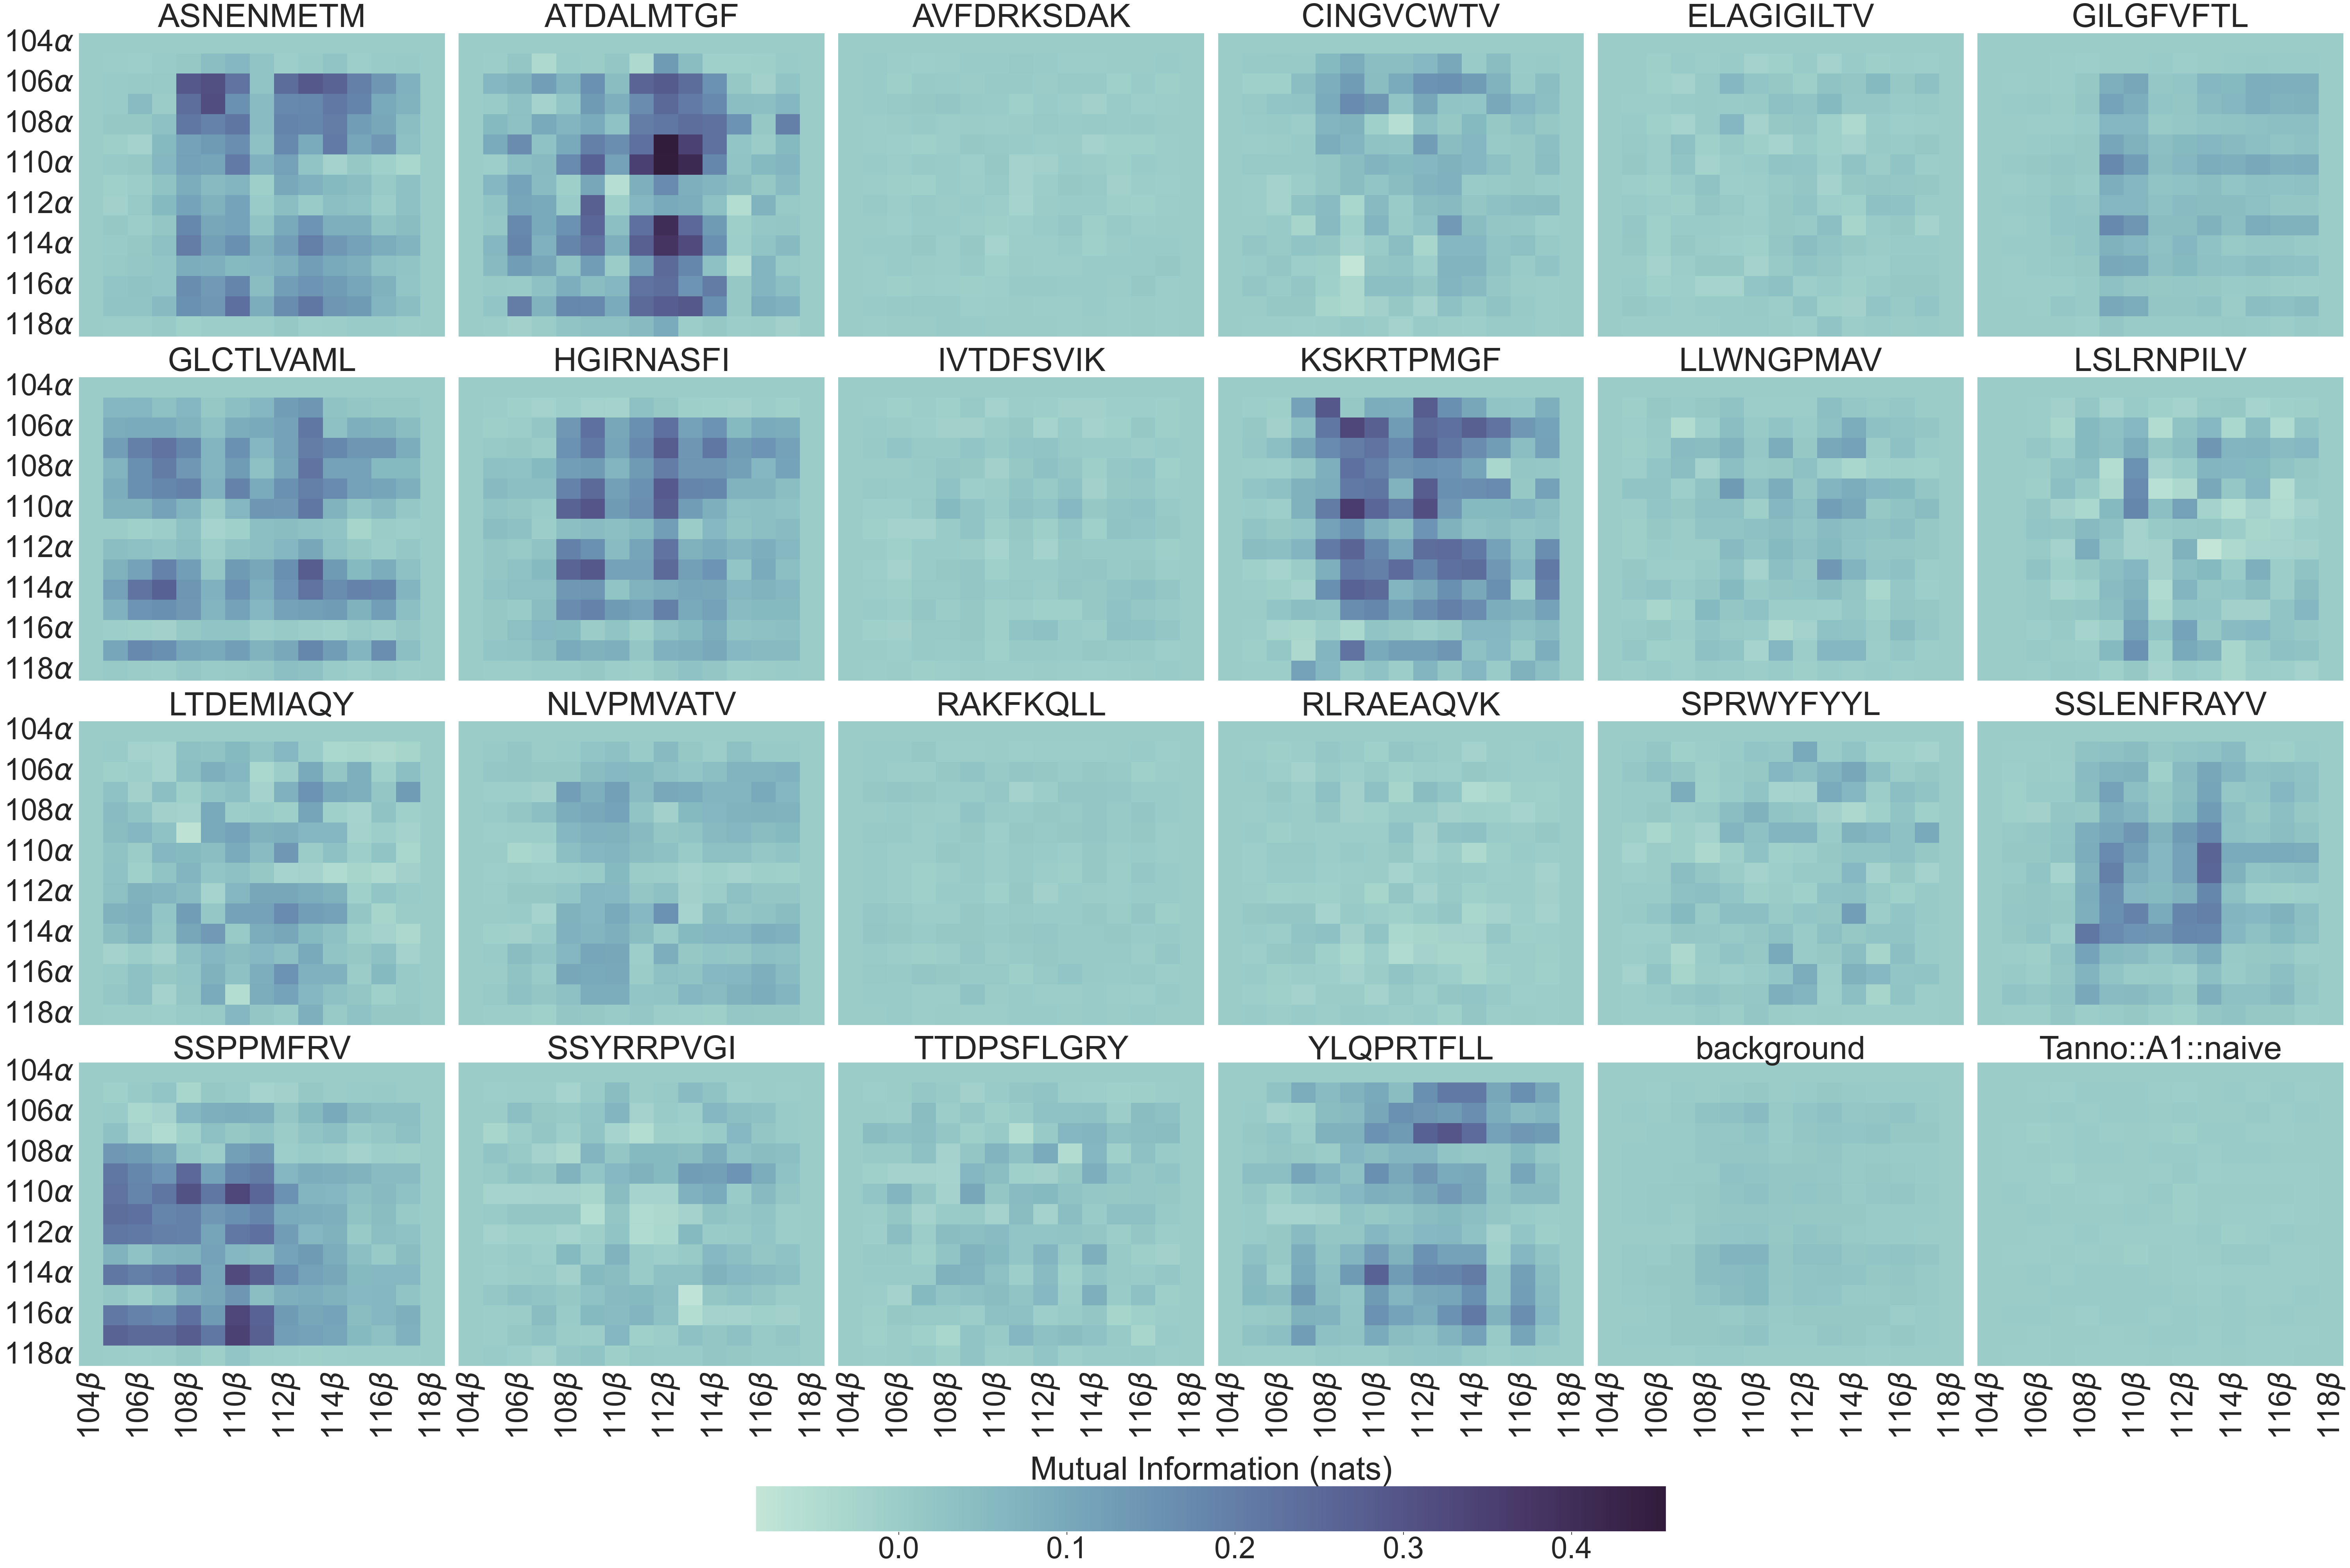

             104$\beta$  105$\beta$  106$\beta$  107$\beta$  108$\beta$  \
104$\alpha$         NaN         NaN         NaN         NaN         NaN   
105$\alpha$         NaN         1.0         NaN         1.0         NaN   
106$\alpha$         NaN         1.0         1.0         1.0         1.0   
107$\alpha$         NaN         1.0         1.0         1.0         1.0   
108$\alpha$         NaN         1.0         1.0         1.0         1.0   
109$\alpha$         NaN         1.0         1.0         1.0         1.0   
110$\alpha$         NaN         1.0         1.0         1.0         1.0   
111$\alpha$         NaN         1.0         1.0         NaN         1.0   
112$\alpha$         NaN         1.0         1.0         NaN         1.0   
113$\alpha$         NaN         1.0         1.0         1.0         1.0   
114$\alpha$         NaN         1.0         1.0         1.0         1.0   
115$\alpha$         NaN         1.0         1.0         1.0         1.0   
116$\alpha$         NaN  

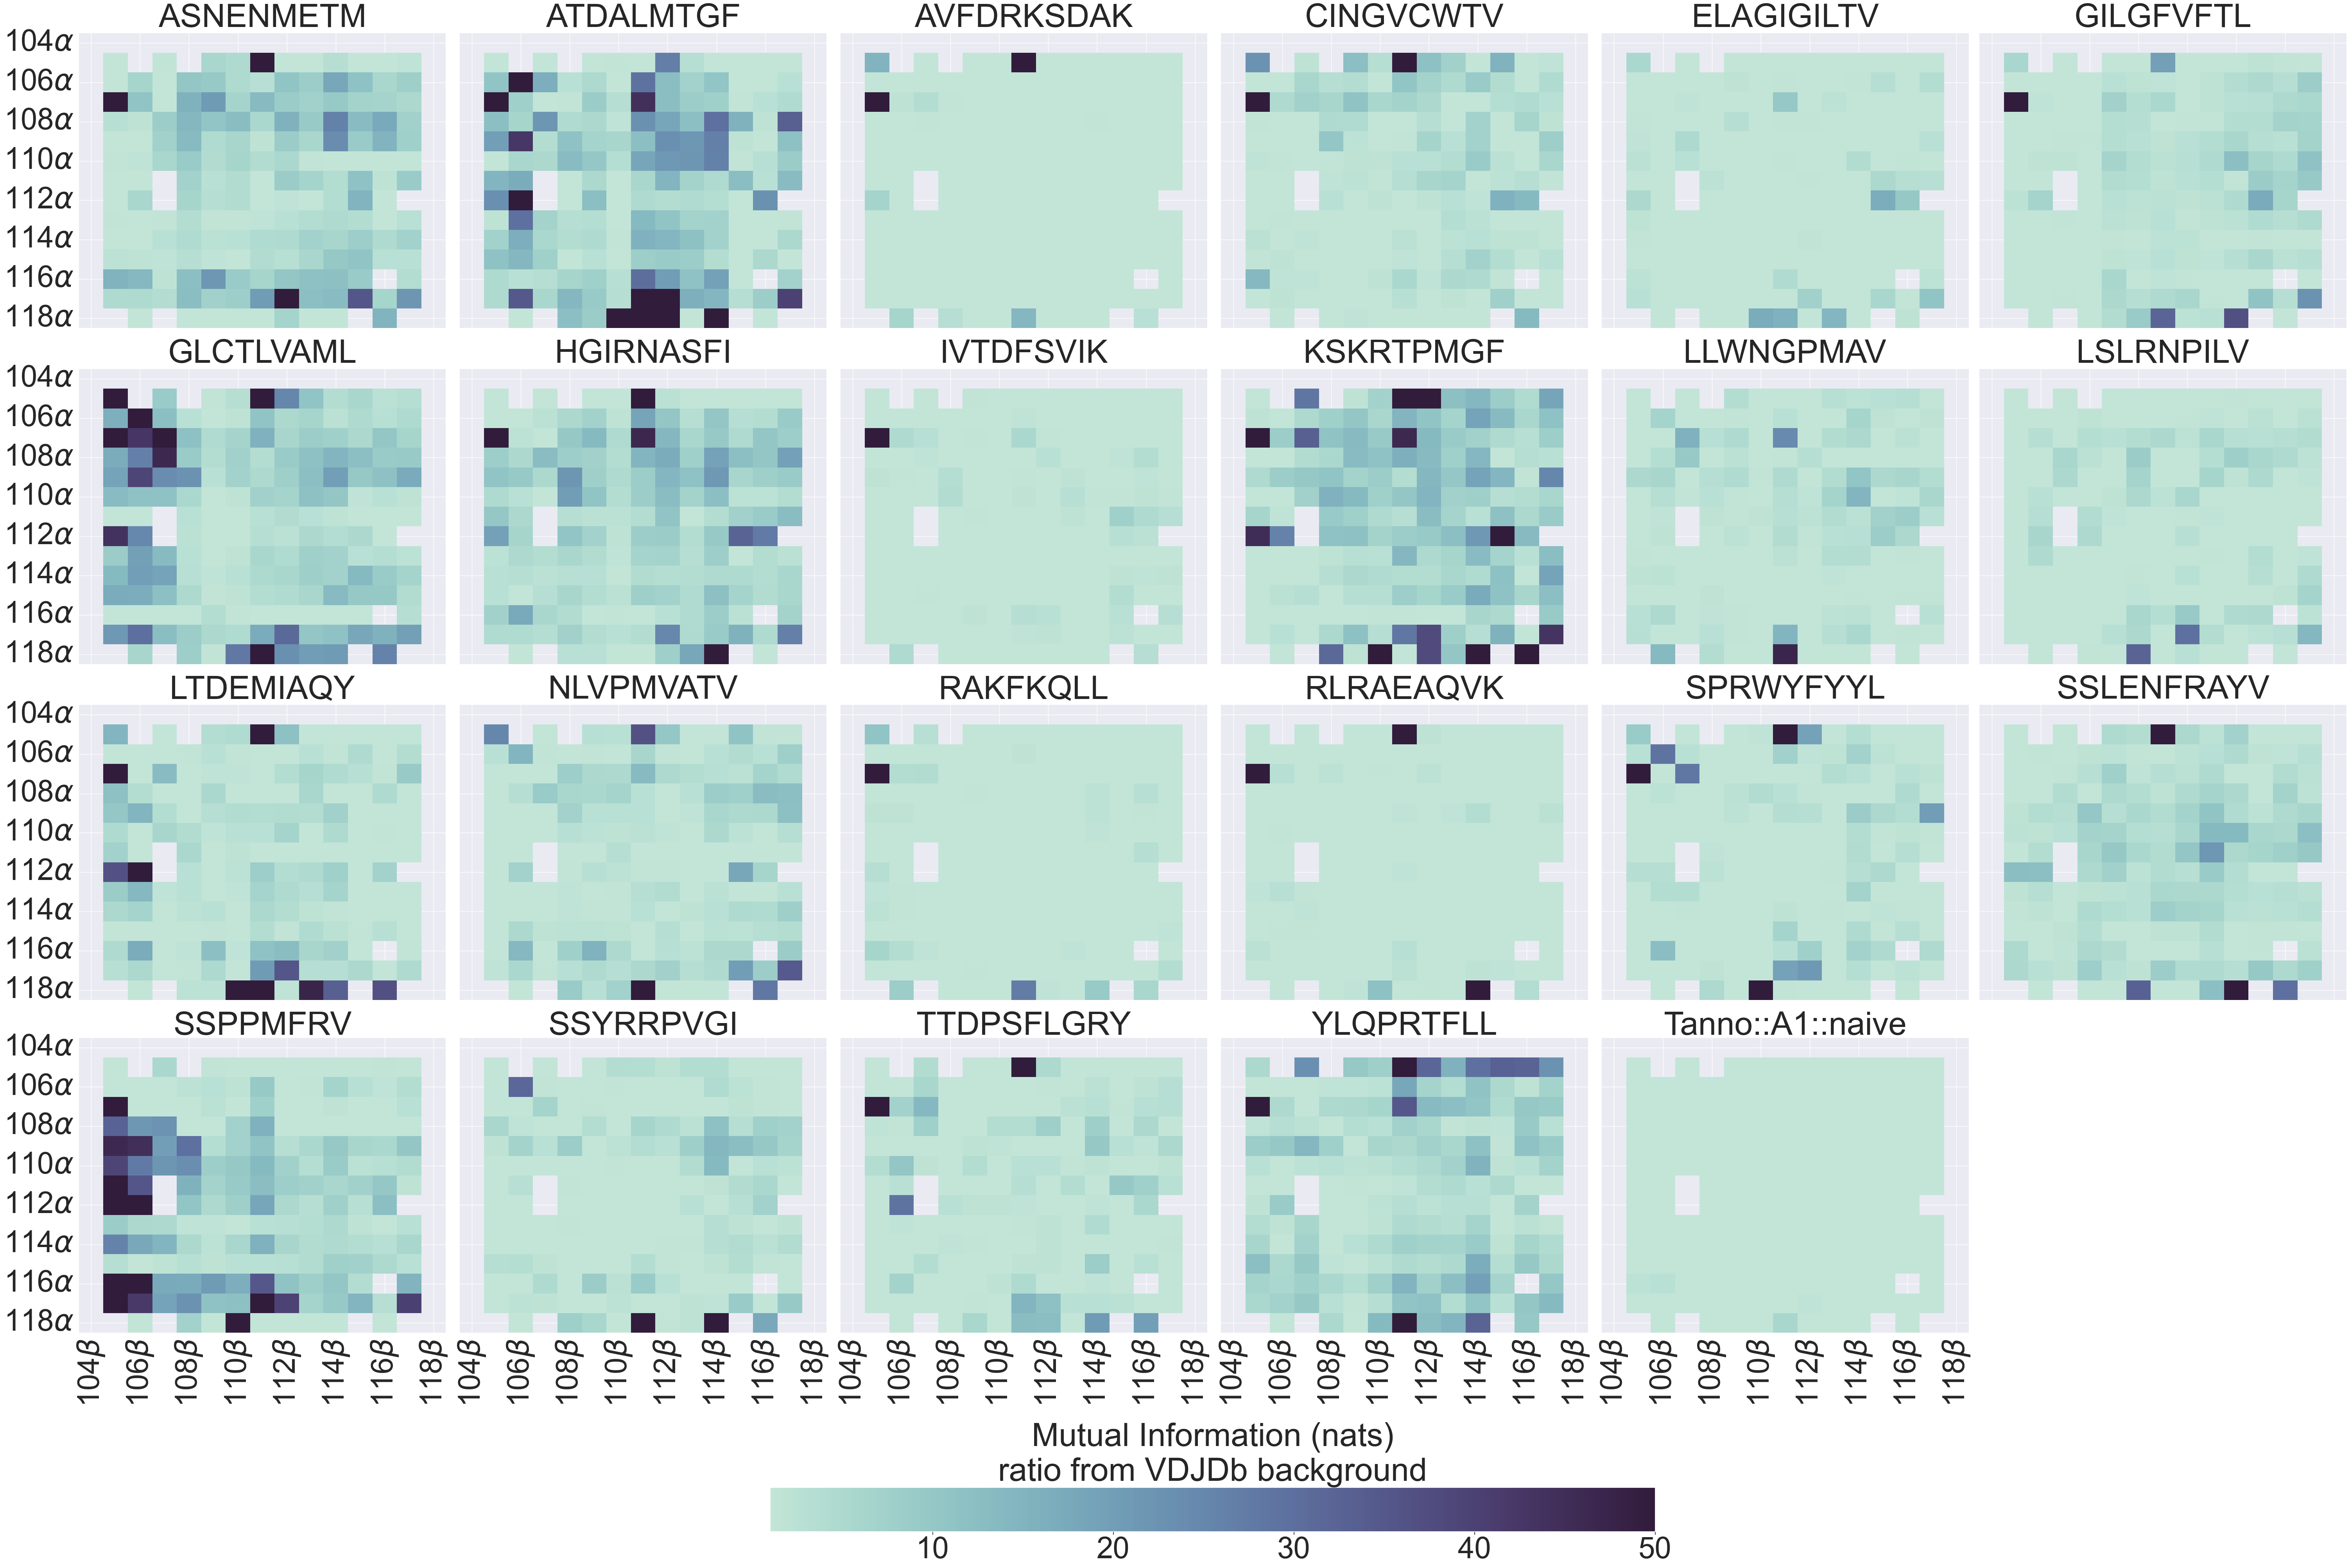

In [15]:
sns.set(font_scale=5)

all_epitopes = pd.read_csv('data/output/mutual_info/estimated_mutual_info_all_epitopes_CDR3ab_by_pos_all_epitopes_w_studyspecific_shuffle_wdupl.csv', index_col = 0)
# print(all_epitopes)
diffs={}

for x, ep in enumerate(sorted(vdj['Epitope'].unique().tolist())+ ['background', 'Tanno::A1::naive']):
    # X = pd.read_csv('data/output/mutual_info/mutual_info_cdr3ab_array_'+ k + '.csv', index_col=0)
    epdf = all_epitopes.loc[all_epitopes['epitope'] == ep]
    diff = epdf.loc[epdf['type'] == 'real'][[c for c in epdf.columns if c not in ['epitope', 'type']]].values - epdf.loc[epdf['type'] == 'shuffle'][[c for c in epdf.columns if c not in ['epitope', 'type']]].values
    X = pd.DataFrame(diff.reshape(19,19))

    X.columns=[str(x) + r'$\beta$' for x in cdr3_res]
    X.index=[str(x) + r'$\alpha$' for x in cdr3_res]
    X = X.drop([r'112.1$\beta$', r'111.1$\beta$', r'112.2$\beta$', r'111.2$\beta$'], axis=1)
    X = X.drop([r'112.1$\alpha$', r'111.1$\alpha$', r'112.2$\alpha$', r'111.2$\alpha$'], axis=0)
    # print(np.nanmax(X.values))
    # X[X < 0] = 0
    diffs[ep] = X

f, axs = plt.subplots(figsize=(60,40), ncols=6, nrows=4, sharex = 'col', sharey='row', constrained_layout=True)
ax = axs.ravel()
vmax = np.nanmax([np.nanmax(diffs[x]) for x in diffs])
vmin = np.nanmin([np.nanmin(diffs[x]) for x in diffs])
for x, ep in enumerate(sorted(vdj['Epitope'].unique().tolist())+ ['background', 'Tanno::A1::naive']):
    m=sns.heatmap(diffs[ep],
                cmap = p, ax = ax[x], cbar=False, vmin=vmin, vmax=vmax)
    ax[x].set_title(ep)

cbar = f.colorbar(m.get_children()[0], ax=axs[-1,:], orientation="horizontal")
cbar.ax.set_title('Mutual Information (nats)')
plt.savefig(f2 + 'MutualInformation_cdr3a_cdr3b_w_studyspecific_shuffle_wdupl.png')
plt.show()

X0 = diffs['background']
X0[X0 < 0] = 0
diffs_FC = {x:diffs[x]/X0 for x in diffs}
print(diffs_FC['background'])
print(diffs_FC[vdj['Epitope'].unique().tolist()[0]])

f, axs = plt.subplots(figsize=(60,40), ncols=6, nrows=4, sharex = 'col', sharey='row', constrained_layout=True)
ax = axs.ravel()
vmax = 50
vmin = 1
for x, ep in enumerate(sorted(vdj['Epitope'].unique().tolist())+ ['Tanno::A1::naive']):
    m=sns.heatmap(diffs_FC[ep],
                cmap = p, ax = ax[x], cbar=False, vmin=vmin, vmax=vmax)
    ax[x].set_title(ep)

cbar = f.colorbar(m.get_children()[0], ax=axs[-1,:], orientation="horizontal")
cbar.ax.set_title('Mutual Information (nats)\nratio from VDJDb background')
f.delaxes(ax[-1])
plt.savefig(f2 + 'MutualInformation_cdr3a_cdr3b_FC_w_studyspecific_shuffle_wdupl.png')
plt.show()

In [16]:
MIdf=pd.DataFrame()
for ep in corrected_matrices.keys():
    MIdf.loc[ep, 'cdr3a-cdr3b MI'] = corrected_matrices[ep].loc['CDR3b', 'CDR3a']
    MIdf.loc[ep, 'Va-cdr3a MI'] = corrected_matrices[ep].loc['CDR3a', 'Va']
    MIdf.loc[ep, 'Vb-cdr3b MI'] = corrected_matrices[ep].loc['CDR3b', 'Vb']

print(MIdf)

                  cdr3a-cdr3b MI  Va-cdr3a MI  Vb-cdr3b MI
ELAGIGILTV              1.379637     1.484372     1.518538
GILGFVFTL               7.639425     5.426634     2.898515
NLVPMVATV               6.868004     3.914855     2.762782
GLCTLVAML              16.062084     5.304432     7.013391
SSLENFRAYV             10.174751     4.991621     2.913364
ASNENMETM              15.280333     3.622836     5.342179
YLQPRTFLL              13.858483     4.257697     3.568180
LLWNGPMAV               4.533047     3.672731     2.380854
CINGVCWTV               6.338333     3.703207     2.270201
KSKRTPMGF              20.567779     4.263918     4.319511
ATDALMTGF              20.714320     5.865221     5.004247
AVFDRKSDAK              0.195429     2.881576     1.768134
IVTDFSVIK               0.883411     5.412946     4.460112
RAKFKQLL                0.941519     5.920283     4.652013
RLRAEAQVK              -0.198462     2.685778     1.437306
HGIRNASFI              15.174504     4.902621     4.6092

I want to correlate CDR3a/b and V/cdr3 MI with SASA

In [17]:
# manually calculated SASA with pymol
sasa  = {
    'RAKFKQLL':243,
    'NLVPMVATV':375,
    'GLCTLVAML':341,
    'SSLENFRAYV':464,
    'YLQPRTFLL':460,
    'LLWNGPMAV':307,
    'ELAGIGILTV':329,
    'CINGVCWTV':264,
    'LSLRNPILV':308,
    'SSYRRPVGI':331,
    'SPRWYFYYL':436,
    'GILGFVFTL':259, 
    'ASNENMETM':311
}
sasa = pd.Series(sasa)
print(sasa)

RAKFKQLL      243
NLVPMVATV     375
GLCTLVAML     341
SSLENFRAYV    464
YLQPRTFLL     460
LLWNGPMAV     307
ELAGIGILTV    329
CINGVCWTV     264
LSLRNPILV     308
SSYRRPVGI     331
SPRWYFYYL     436
GILGFVFTL     259
ASNENMETM     311
dtype: int64


In [18]:
import statsmodels.formula.api as smf
from sklearn.preprocessing import PolynomialFeatures


def simple_regplot_parabola(x_name, y_name, df,
        n_std=2, n_pts=100, ax=None, scatter_kws=None, line_kws=None, ci_kws=None
):
    """ Draw a regression line with error interval. """
    ax = plt.gca() if ax is None else ax

    # calculate best-fit line and interval
    formula = y_name + ' ~ ' + x_name + ' + I(' + x_name + '**2)'
    fit_results = smf.ols(formula, data=df).fit()

    print(fit_results.summary())
    pval = fit_results.f_pvalue
    Rsq = fit_results.rsquared
    Rsq_adj = fit_results.rsquared_adj
    print('pval, Rsq:', pval, Rsq)
    if pval<0.05:
        line_kws={'color':'red'}
        ci_kws={'color':'red'}
    else:
        line_kws={'color':'k'}
        ci_kws={'color':'k'}

    eval_x = pd.DataFrame(np.linspace(np.min(df[x_name]), np.max(df[x_name]), n_pts), columns=['sasa'])
    # print(eval_x)
    pred = fit_results.get_prediction(eval_x, transform=True)
    # print(pred.predicted_mean)

    # draw the fit line and 95% CI
    ci_kws = {} if ci_kws is None else ci_kws
    df_predictions = pred.summary_frame(alpha=0.05)
    ax.fill_between(
        eval_x['sasa'],
        df_predictions.mean_ci_lower,
        df_predictions.mean_ci_upper,
        alpha=0.5,
        **ci_kws,
    )
    line_kws = {} if line_kws is None else line_kws
    h = ax.plot(eval_x['sasa'], pred.predicted_mean, **line_kws)

    # draw the scatterplot
    scatter_kws = {} if scatter_kws is None else scatter_kws
    ax.scatter(df[x_name], df[y_name], c=h[0].get_color())#, **scatter_kws)

    return pval, Rsq, Rsq_adj, fit_results

cdr3a-cdr3b MI
                            OLS Regression Results                            
Dep. Variable:         cdr3a_cdr3b_MI   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                 -0.067
Method:                 Least Squares   F-statistic:                    0.6235
Date:                Wed, 24 Jun 2026   Prob (F-statistic):              0.556
Time:                        17:51:58   Log-Likelihood:                -38.587
No. Observations:                  13   AIC:                             83.17
Df Residuals:                      10   BIC:                             84.87
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -5.9819     40.94

/Users/milighm/miniforge3/envs/MutualInformation/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1772: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=13
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "
/Users/milighm/miniforge3/envs/MutualInformation/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1772: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=13
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "
/Users/milighm/miniforge3/envs/MutualInformation/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1772: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=13
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


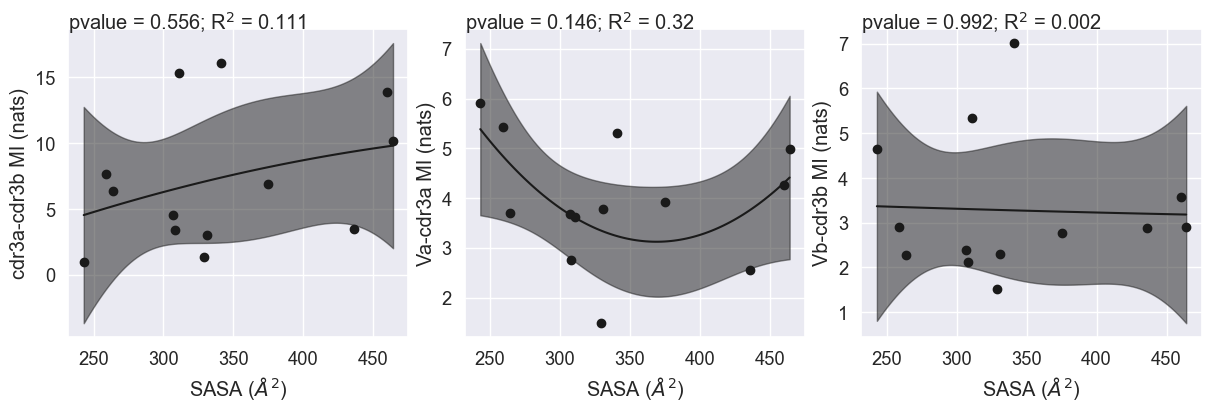

In [19]:
X1 = pd.merge(MIdf, pd.DataFrame(sasa, columns=['sasa']), left_index=True, right_index=True)
X1.columns = [x.replace('-','_').replace(' ','_') for x in X1.columns]

sns.set(font_scale=1.2)
f, ax = plt.subplots(nrows=1, ncols = 3, figsize=(12,4), sharex='col', constrained_layout=True)

for j, c1 in enumerate(MIdf.columns):
    print(c1)
    pval,Rsq, Rsq_adj, _ = simple_regplot_parabola('sasa', c1.replace('-','_').replace(' ','_'), X1, ax=ax[j])
    ax[j].annotate('pvalue = ' + str(pval.round(3)) + r'; R$^2$ = ' + str(Rsq.round(3)),(0,1), xycoords='axes fraction')
    ax[j].set_xlabel(r'SASA ($\AA^2$)')
    ax[j].set_ylabel(c1 + ' (nats)')
plt.savefig(f2 + 'MutualInformation_vs_sasa_corr_w_studyspecific_shuffle_wdupl.png')
plt.show()

In [20]:
def hamming_distance(s1, s2):
    if len(s1) != len(s2):
        print(s1)
        print(s2)
        raise ValueError("Strand lengths are not equal!")
    return sum(ch1 != ch2 for ch1,ch2 in zip(s1,s2))

In [21]:
import statsmodels.api as sm


def simple_regplot(x_name,
    x, y, n_std=2, n_pts=100, ax=None, scatter_kws=None, line_kws=None, ci_kws=None
):
    """ Draw a regression line with error interval. """
    ax = plt.gca() if ax is None else ax

    # calculate best-fit line and interval
    x_fit = sm.add_constant(x)
    fit_results = sm.OLS(y, x_fit).fit()

    print(fit_results.summary())
    pval = fit_results.f_pvalue
    Rsq = fit_results.rsquared
    Rsq_adj = fit_results.rsquared_adj
    if (pval<0.05):
        line_kws={'color':'red'}
        ci_kws={'color':'red'}
    else:
        line_kws={'color':'k'}
        ci_kws={'color':'k'}

    eval_x = sm.add_constant(np.linspace(np.min(x), np.max(x), n_pts))
    pred = fit_results.get_prediction(eval_x)

    # draw the fit line and 95% CI
    ci_kws = {} if ci_kws is None else ci_kws
    df_predictions = pred.summary_frame(alpha=0.05)
    ax.fill_between(
        eval_x[:, 1],
        df_predictions.mean_ci_lower,
        df_predictions.mean_ci_upper,
        alpha=0.5,
        **ci_kws,
    )
    line_kws = {} if line_kws is None else line_kws
    h = ax.plot(eval_x[:, 1], pred.predicted_mean, **line_kws)

    # draw the scatterplot
    scatter_kws = {} if scatter_kws is None else scatter_kws
    ax.scatter(x, y, c=h[0].get_color())#, **scatter_kws)

    return pval, Rsq, Rsq_adj, fit_results

In [22]:
# calculate effective set size
effective_set_size = []

for ep in sorted(vdj['Epitope'].unique().tolist()):
    print(ep)
    epset = vdj.loc[vdj['Epitope'] == ep]
    cdr3a = epset['cdr3a_IMGTgaps_padded'].tolist()
    cdr3a = [a.split(', ') for a in cdr3a]
    cdr3a = [a[3:-3] for a in cdr3a]
    cdr3b = epset['cdr3b_IMGTgaps_padded'].tolist()
    cdr3b = [b.split(', ') for b in cdr3b]
    cdr3b = [b[3:-3] for b in cdr3b]

    assert len(cdr3a) == len(cdr3b)
    ab = list(zip(cdr3a, cdr3b))
    # print(cdr3a)
    # print(cdr3b)
    # print(ab)

    ess_a = sum([1/len([y for y in cdr3a if hamming_distance(x,y) < 2]) for x in cdr3a])/epset.shape[0]
    ess_b = sum([1/len([y for y in cdr3b if hamming_distance(x,y) < 2]) for x in cdr3b])/epset.shape[0]

    ess_ab = sum([1/len([y for y in ab if hamming_distance(x[0],y[0]) + hamming_distance(x[1],y[1]) < 3]) for x in ab])/epset.shape[0]
    # print(ep, ess_ab, len(ab))
    effective_set_size.append((ep, ess_a, ess_b, ess_ab, len(ab)))

ASNENMETM
ATDALMTGF
AVFDRKSDAK
CINGVCWTV
ELAGIGILTV
GILGFVFTL
GLCTLVAML
HGIRNASFI
IVTDFSVIK
KSKRTPMGF
LLWNGPMAV
LSLRNPILV
LTDEMIAQY
NLVPMVATV
RAKFKQLL
RLRAEAQVK
SPRWYFYYL
SSLENFRAYV
SSPPMFRV
SSYRRPVGI
TTDPSFLGRY
YLQPRTFLL


In [23]:
effective_set_size = pd.DataFrame(effective_set_size, columns=['epitope','effective_set_size_a','effective_set_size_b','effective_set_size','N'])

In [24]:
effective_set_size

,epitope,effective_set_size_a,effective_set_size_b,effective_set_size,N
0,ASNENMETM,0.599252,0.406905,0.655642,196
1,ATDALMTGF,0.625384,0.784000,0.832667,125
2,AVFDRKSDAK,0.670070,0.899647,0.991713,1699
3,CINGVCWTV,0.844448,0.898894,0.977876,226
4,ELAGIGILTV,0.622693,0.886542,1.000000,374
5,GILGFVFTL,0.338891,0.344243,0.615703,1853
6,GLCTLVAML,0.497164,0.517192,0.758465,342
7,HGIRNASFI,0.501559,0.510771,0.727253,243
8,IVTDFSVIK,0.650214,0.728693,0.956913,704
9,KSKRTPMGF,0.764966,0.620335,0.789116,98


In [25]:
X2 = pd.merge(effective_set_size, MIdf, right_index=True, left_on='epitope')

                            OLS Regression Results                            
Dep. Variable:         cdr3a-cdr3b MI   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     3.250
Date:                Wed, 24 Jun 2026   Prob (F-statistic):             0.0865
Time:                        17:52:57   Log-Likelihood:                -72.112
No. Observations:                  22   AIC:                             148.2
Df Residuals:                      20   BIC:                             150.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.6022      1.943      5.457      0.0

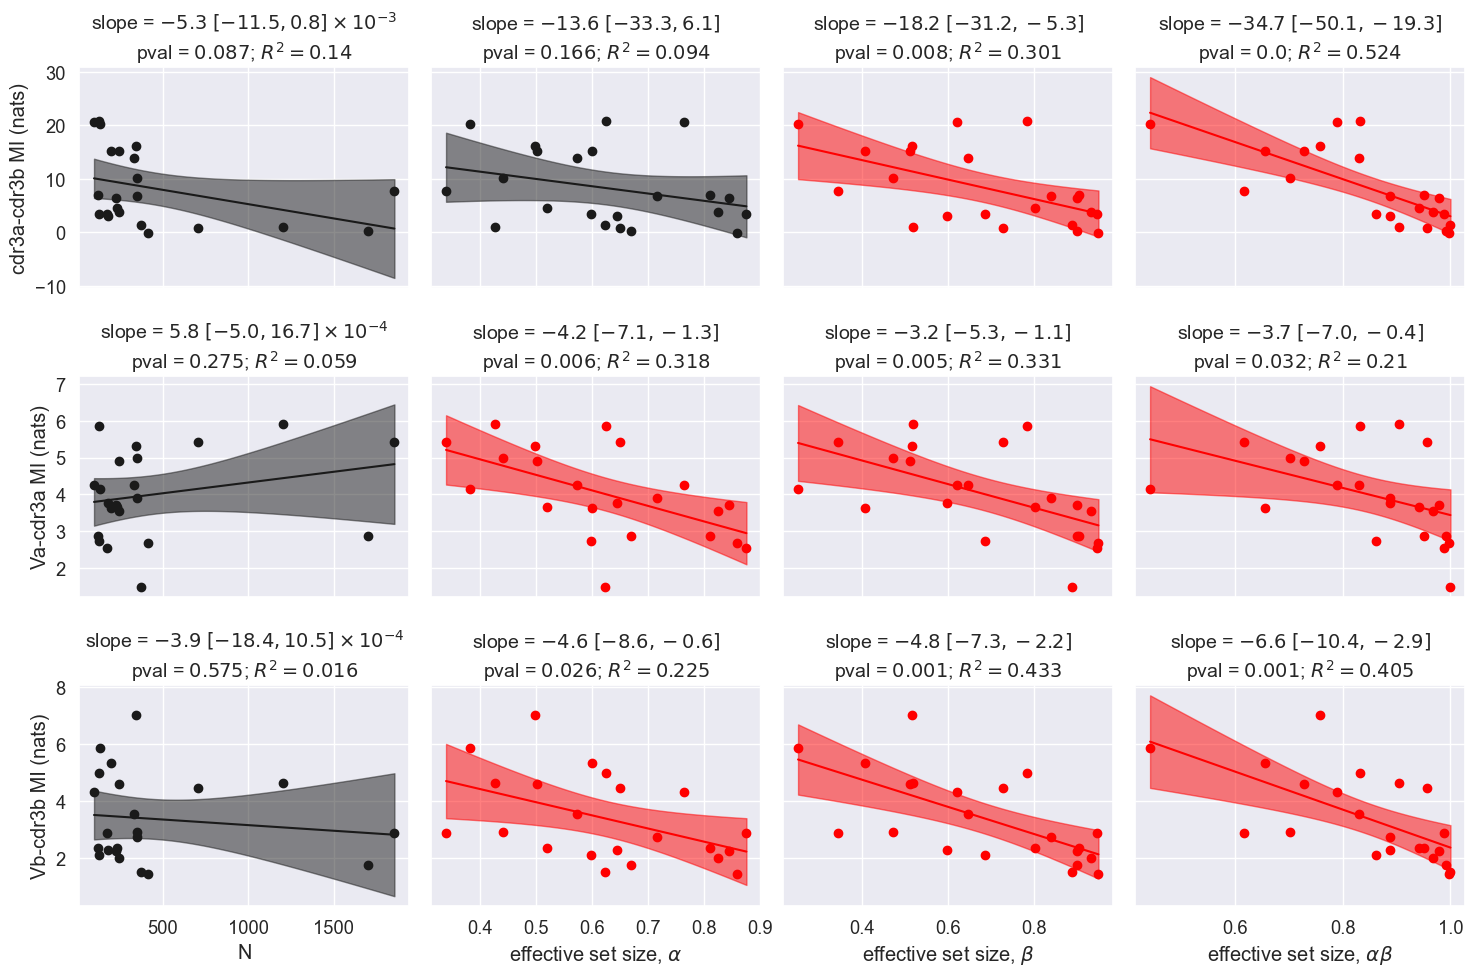

In [26]:
labels = {'effective_set_size_a':r'effective set size, $\alpha$',
          'effective_set_size_b':r'effective set size, $\beta$',
          'effective_set_size':r'effective set size, $\alpha\beta$',
          'N':'N'}

sns.set(font_scale=1.2)
f, ax = plt.subplots(nrows=3, ncols = 4, figsize=(15,10), sharex='col', sharey='row')

from math import log10, floor

def sci_notation_mantissa(value, exp, decimals=1):
    """Return just the mantissa for a given exponent."""
    mantissa = value / 10**exp
    return f"{mantissa:.{decimals}f}"

for i, c2 in enumerate(['N','effective_set_size_a', 'effective_set_size_b', 'effective_set_size']):
    for j, c1 in enumerate(MIdf.columns):
        pval,Rsq, Rsq_adj, fit = simple_regplot(c2, X2[c2], X2[c1], ax=ax[j,i])

        slope = fit.params[c2]
        slope_ci = fit.conf_int(alpha=0.05)
        exp = floor(log10(abs(slope)))
        ci_lower, ci_upper = slope_ci.iloc[1, 0], slope_ci.iloc[1, 1]
        # ci_half = (ci_upper - ci_lower) / 2

        if c2 != 'N':
            ax[j, i].set_title(f'slope = ${slope:.1f}$ $[{ci_lower:.1f}, {ci_upper:.1f}]$'
                               f'\npval = ${pval.round(3)}$'
                               f'; $R^2 = {Rsq.round(3)}$' , fontsize=14)
        else:
            ax[j, i].set_title(
                f'slope = ${sci_notation_mantissa(slope, exp)}$ '
                f'$[{sci_notation_mantissa(ci_lower, exp)}, {sci_notation_mantissa(ci_upper, exp)}]'
                f'\\times 10^{{{exp}}}$\n'
                f'pval = ${round(pval, 3)}$; $R^2 = {round(Rsq, 3)}$',
                fontsize=14
            )
        
        
        # ax[j,i].annotate(f'pval = {pval.round(3)}\nslope = {slope.round(3)}' + r'; R$^2$ = ' + str(Rsq.round(3)),(0,1), xycoords='axes fraction')
        if i == 0:
            ax[j,i].set_ylabel(c1 + ' (nats)')
        if j == 2:
            ax[j,i].set_xlabel(labels[c2])
        # ax[j,i].set_xscale('log')
plt.tight_layout()
plt.savefig(f2 + 'MutualInformation_vs_effective_set_size_w_studyspecific_shuffle_withintriplehamming_wdupl.png')
plt.show()

0         Ja-CDR3a
1         Ja-CDR3b
2            Ja-Jb
3         Jb-CDR3a
4         Jb-CDR3b
          ...     
355       Vb-CDR3a
356       Vb-CDR3b
357          Vb-Ja
358          Vb-Jb
359    CDR3a-CDR3b
Name: pair, Length: 360, dtype: object
Ja-CDR3a
                            OLS Regression Results                            
Dep. Variable:                real_MI   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     5.450
Date:                Wed, 24 Jun 2026   Prob (F-statistic):             0.0301
Time:                        17:52:59   Log-Likelihood:                -32.774
No. Observations:                  22   AIC:                             69.55
Df Residuals:                      20   BIC:                             71.73
Df Model:                           1                                         
Covariance Type:            nonr

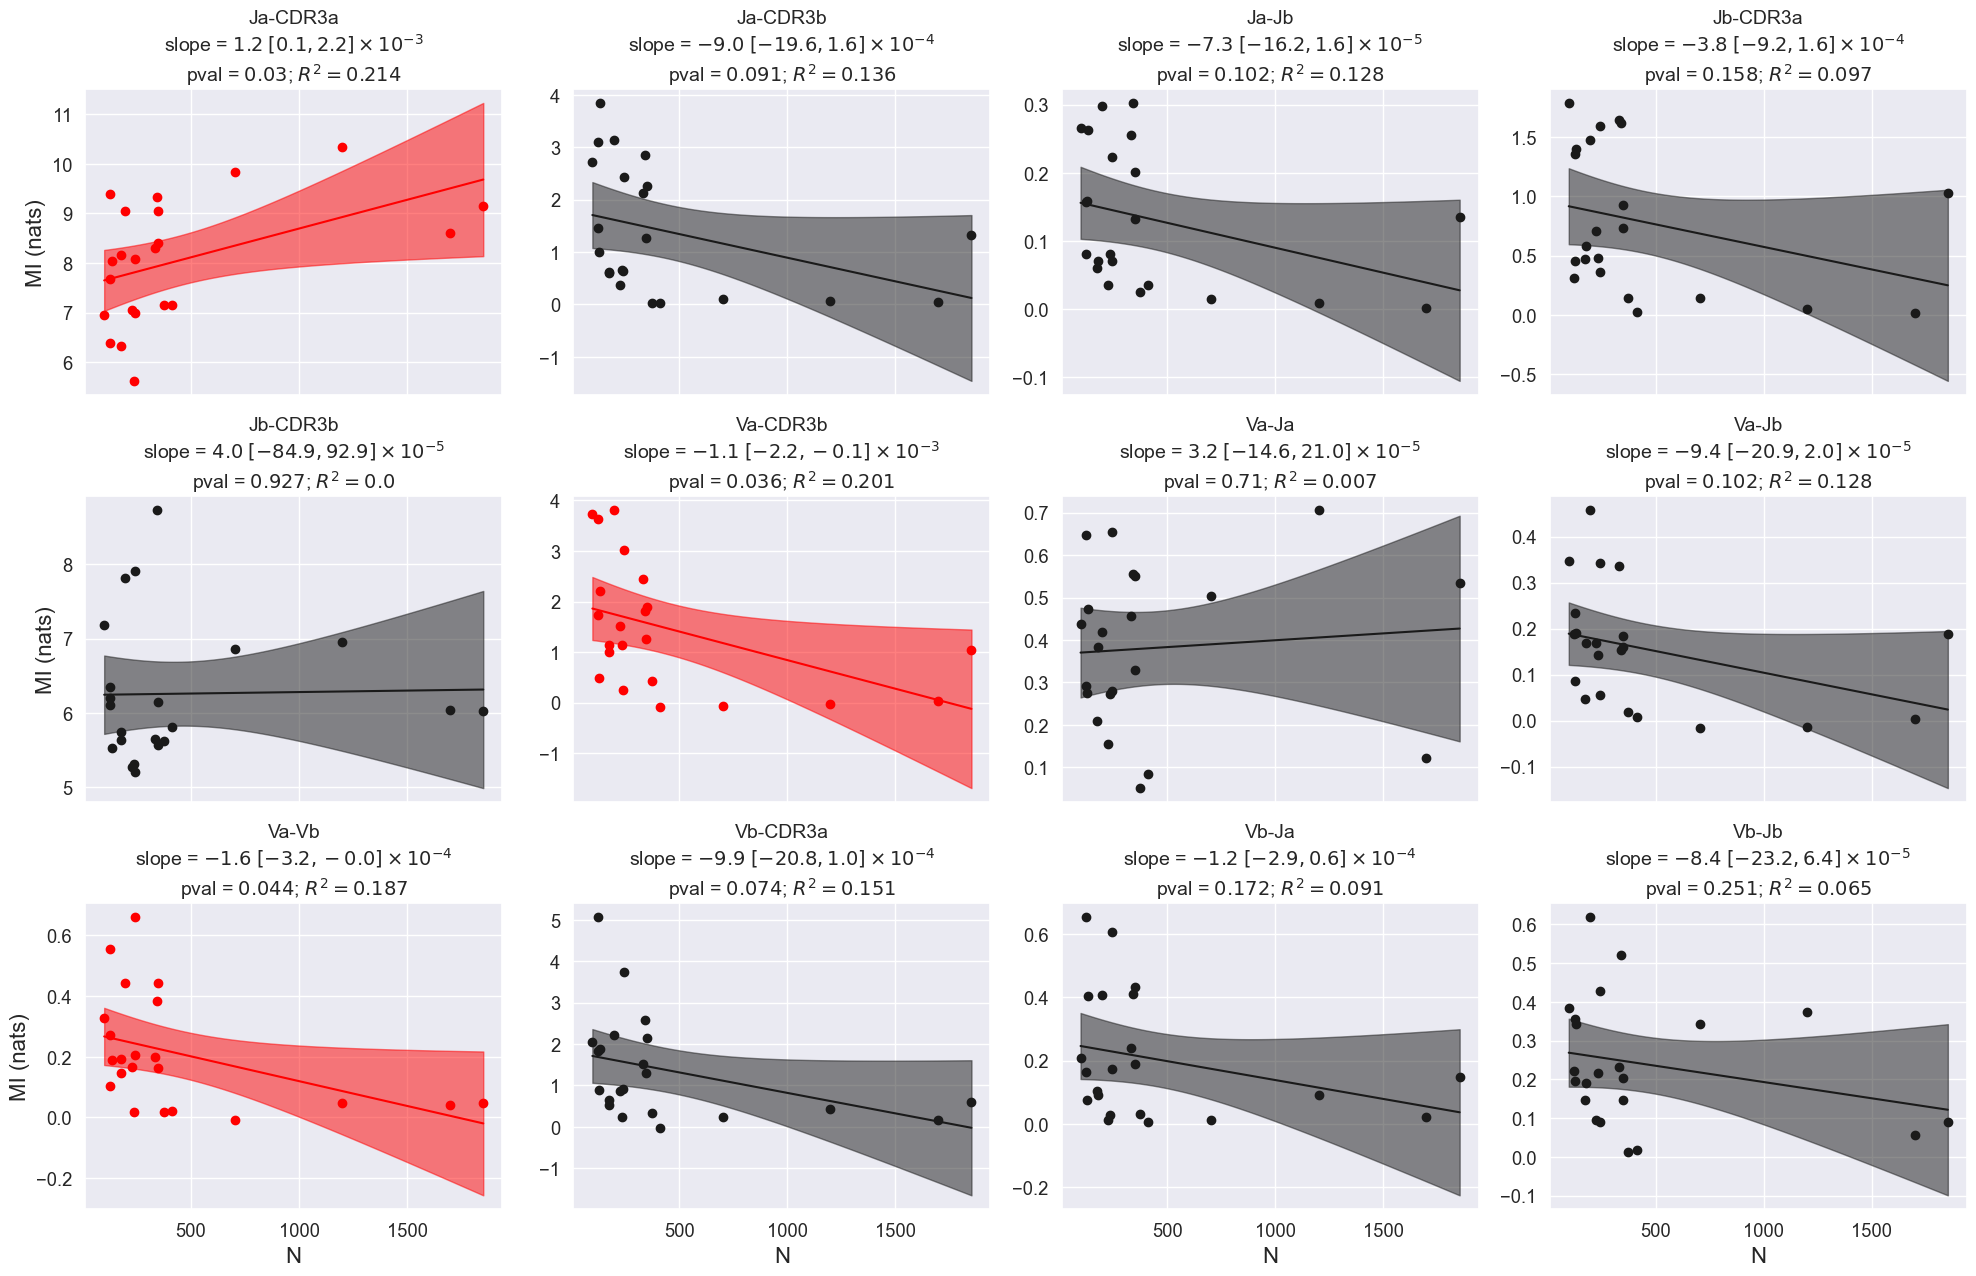

In [27]:
estimatedMI['pair'] = estimatedMI['var1'] + '-' + estimatedMI['var2']
print(estimatedMI['pair'])

fig, axs = plt.subplots(ncols=4, nrows=3, figsize = (20,13), sharex = True)
ax = axs.ravel()
i = 0

for pair in estimatedMI['pair'].unique():
    if pair not in ['CDR3a-CDR3b', 'Va-CDR3a', 'Vb-CDR3b']:
        print(pair)
        p = estimatedMI.loc[estimatedMI['pair'] == pair]
        p = pd.merge(p, effective_set_size)
        c1 = 'real_MI'
        c2 = 'N'
        pval,Rsq,Rsq_adj, fit = simple_regplot(c2, p[c2], p[c1], ax=ax[i])
        slope = fit.params[c2]
        slope_ci = fit.conf_int(alpha=0.05)
        exp = floor(log10(abs(slope)))

        ci_lower, ci_upper = slope_ci.iloc[1, 0], slope_ci.iloc[1, 1]

        ax[i].set_title(
                f'{pair}\n'
                f'slope = ${sci_notation_mantissa(slope, exp)}$ '
                f'$[{sci_notation_mantissa(ci_lower, exp)}, {sci_notation_mantissa(ci_upper, exp)}]'
                f'\\times 10^{{{exp}}}$\n'
                f'pval = ${round(pval, 3)}$; $R^2 = {round(Rsq, 3)}$',
                fontsize=14
            )
        if i%4 == 0:
            ax[i].set_ylabel('MI (nats)', fontsize=16)
        if i >7 :
            ax[i].set_xlabel('N', fontsize=16)
        # ax[j,i].set_xscale('log')
        i+=1
plt.tight_layout()
plt.savefig(f2 + 'MutualInformation_vs_N_w_studyspecific_shuffle_wdupl.png')
plt.show()

Ja-CDR3a
                            OLS Regression Results                            
Dep. Variable:                real_MI   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     3.133
Date:                Wed, 24 Jun 2026   Prob (F-statistic):             0.0919
Time:                        17:53:02   Log-Likelihood:                -33.824
No. Observations:                  22   AIC:                             71.65
Df Residuals:                      20   BIC:                             73.83
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 10.66

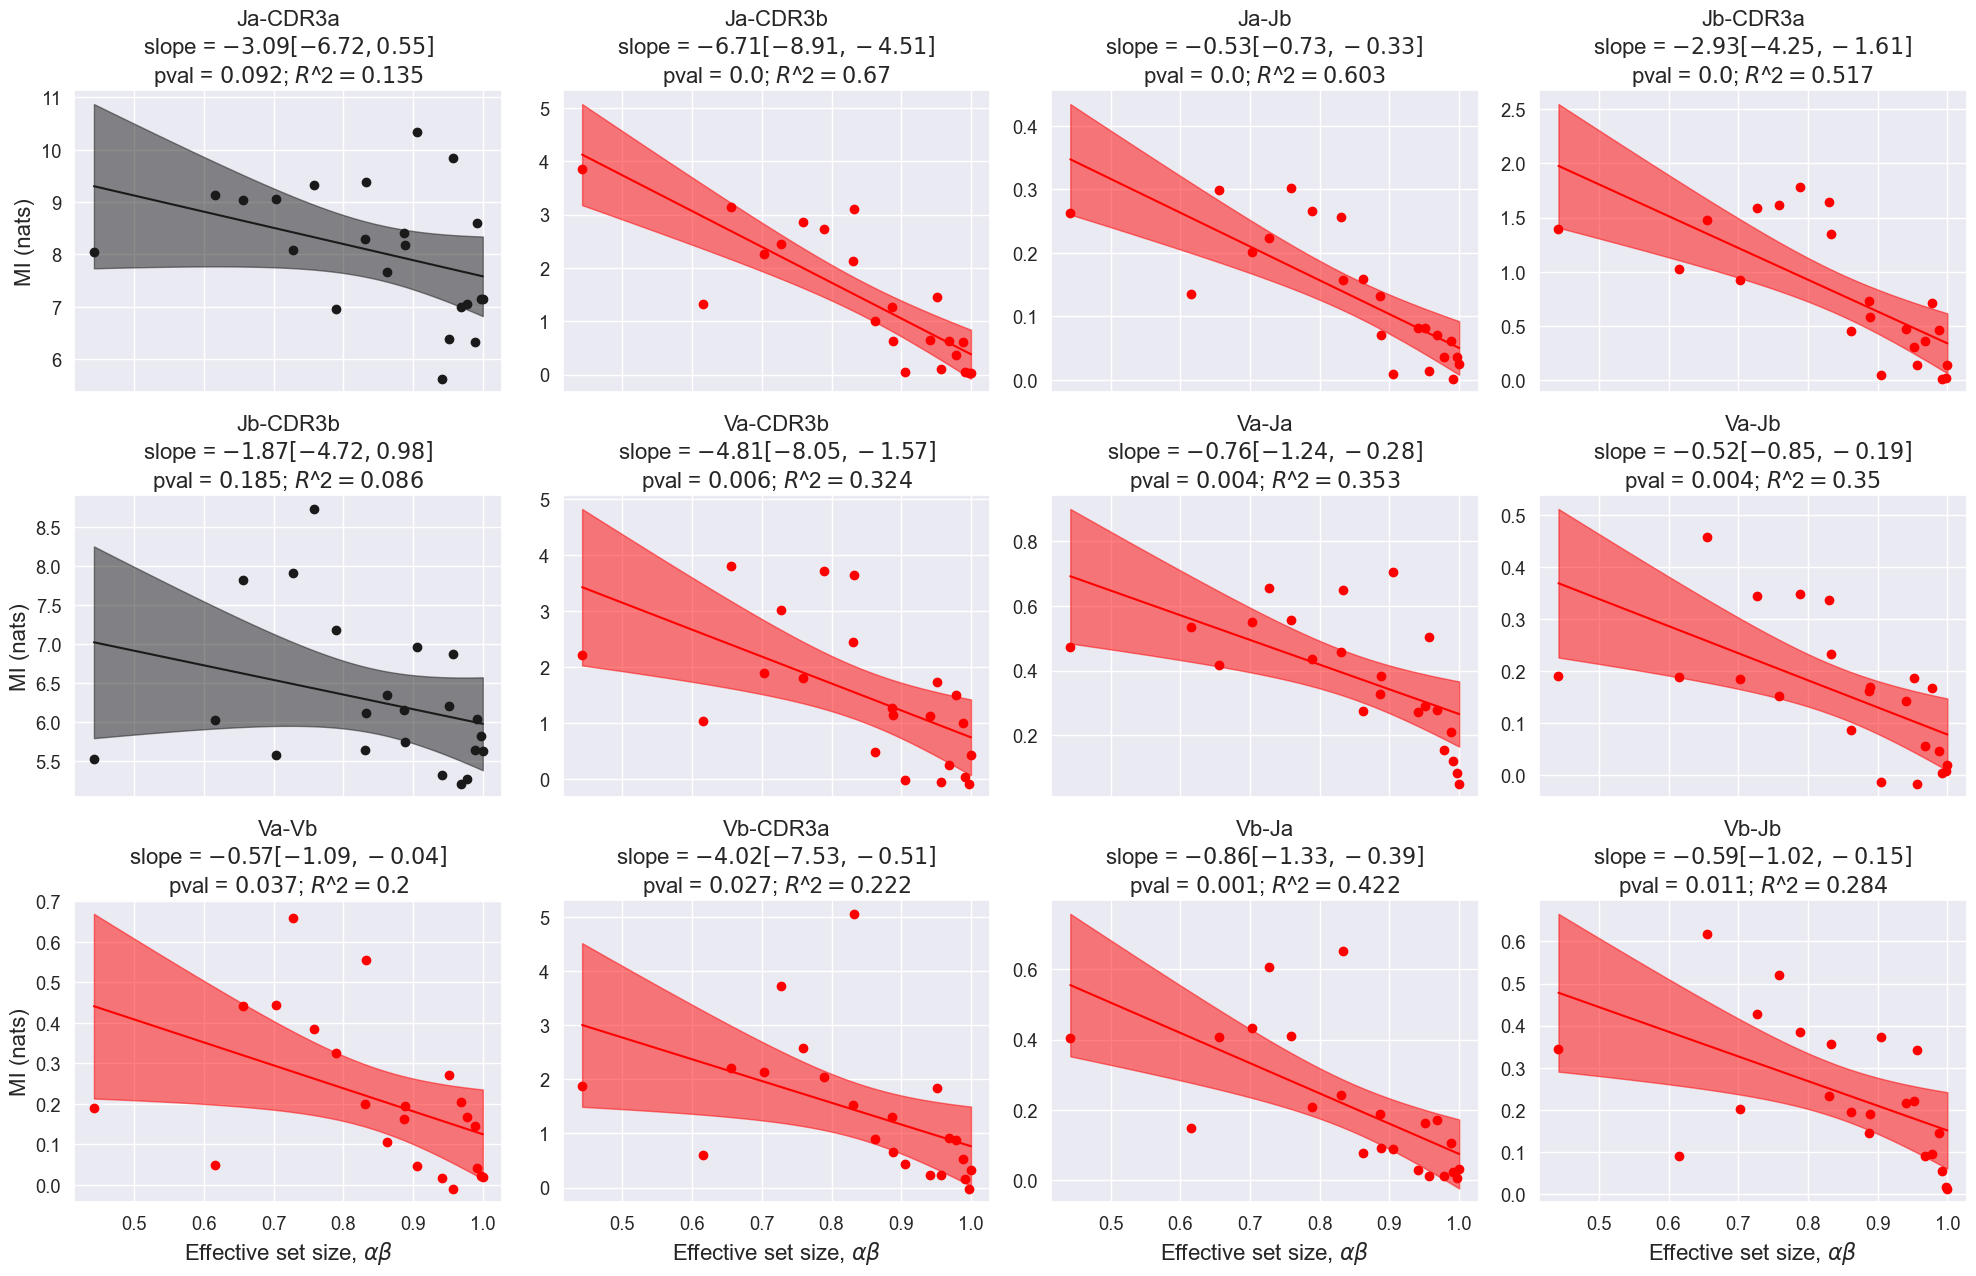

In [28]:
fig, axs = plt.subplots(ncols=4, nrows=3, figsize = (20,13), sharex = True)
ax = axs.ravel()
i=0

for pair in estimatedMI['pair'].unique():
    if pair not in ['CDR3a-CDR3b', 'Va-CDR3a', 'Vb-CDR3b']:
        print(pair)
        p = estimatedMI.loc[estimatedMI['pair'] == pair]
        p = pd.merge(p, effective_set_size)
        c1 = 'real_MI'
        c2 = 'effective_set_size'
        pval,Rsq,R_adj, fit = simple_regplot(c2, p[c2], p[c1], ax=ax[i])

        slope = fit.params[c2]
        slope_ci = fit.conf_int(alpha=0.05)
        exp = floor(log10(abs(slope)))
        ci_lower, ci_upper = slope_ci.iloc[1, 0], slope_ci.iloc[1, 1]
        # ci_half = (ci_upper - ci_lower) / 2

        if c2 != 'N':
            ax[i].set_title(
                f'{pair}\n'
                f'slope = ${slope:.2f}$'
                f'$[{ci_lower:.2f}, {ci_upper:.2f}]$'
                f'\npval = ${pval.round(3)}$; $R$^2$ = {round(Rsq, 3)}$', 
                fontsize=16)
        else:
            ax[i].set_title(
                f'{pair}\n'
                f'slope = ${sci_notation_mantissa(slope, exp)}$ '
                f'$[{sci_notation_mantissa(ci_lower, exp)}, {sci_notation_mantissa(ci_upper, exp)}]'
                f'\\times 10^{{{exp}}}$\n'
                f'pval = ${round(pval, 3)}$; $R^2 = {round(Rsq, 3)}$',
                fontsize=16
            )
        if i%4 == 0:
            ax[i].set_ylabel('MI (nats)', fontsize=16)
        if i >7 :
            ax[i].set_xlabel(r'Effective set size, $\alpha\beta$', fontsize=16)
        # ax[j,i].set_xscale('log')
        i+=1
plt.tight_layout()
plt.savefig(f2 + 'MutualInformation_vs_effective_set_size_all_w_studyspecific_shuffle_withintriplehamming_wdupl.png')
plt.show()

(22, 5)
                             OLS Regression Results                             
Dep. Variable:     effective_set_size_a   R-squared:                       0.132
Model:                              OLS   Adj. R-squared:                  0.088
Method:                   Least Squares   F-statistic:                     3.032
Date:                  Wed, 24 Jun 2026   Prob (F-statistic):             0.0970
Time:                          17:53:04   Log-Likelihood:                 11.265
No. Observations:                    22   AIC:                            -18.53
Df Residuals:                        20   BIC:                            -16.35
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6781   

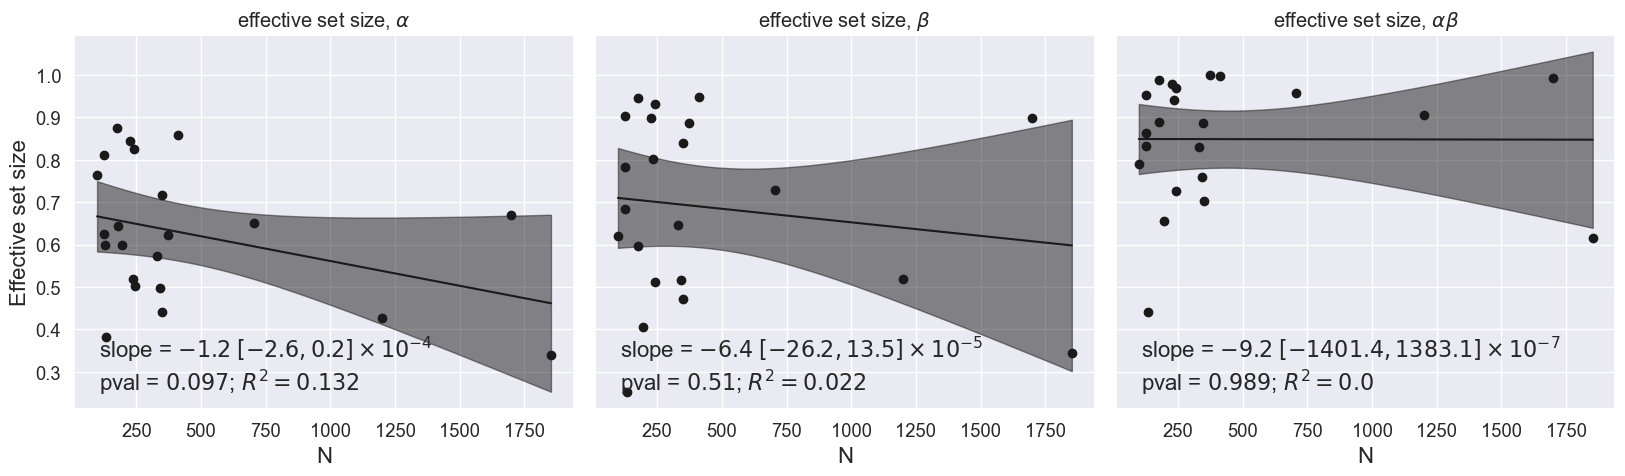

In [29]:
p = effective_set_size[['effective_set_size_a', 'effective_set_size_b', 'effective_set_size', 'N', 'epitope']].drop_duplicates()
print(p.shape)

fig, axs = plt.subplots(ncols=3, nrows=1, figsize = (17,5), sharex = True, sharey=True)
ax = axs.ravel()

for i,c1 in enumerate(['effective_set_size_a', 'effective_set_size_b', 'effective_set_size']):

    c2 = 'N'
    pval,Rsq,R_adj, fit = simple_regplot(c2, p[c2], p[c1], ax=ax[i])
    slope = fit.params[c2]
    slope_ci = fit.conf_int(alpha=0.05)
    exp = floor(log10(abs(slope)))
    ci_lower, ci_upper = slope_ci.iloc[1, 0], slope_ci.iloc[1, 1]
    # ci_half = (ci_upper - ci_lower) / 2

    if c2 != 'N':
        ax[i].annotate(f'slope = {slope:.2f} [{ci_lower:.2f}, {ci_upper:.2f}]\npval = {pval.round(3)}' + r'; R$^2$ = ' + str(Rsq.round(3)),
                       (0.05,.1), xycoords='axes fraction', 
                       fontsize=16)
    else:
        ax[i].annotate(
            f'slope = ${sci_notation_mantissa(slope, exp)}$ '
            f'$[{sci_notation_mantissa(ci_lower, exp)}, {sci_notation_mantissa(ci_upper, exp)}]'
            f'\\times 10^{{{exp}}}$\n'
            f'pval = ${round(pval, 3)}$; $R^2 = {round(Rsq, 3)}$',
            (0.05,0.05), xycoords='axes fraction',
            fontsize=16
        )
    ax[i].set_xlabel('N', fontsize=16)
    ax[i].set_title(labels[c1])
ax[0].set_ylabel('Effective set size', fontsize=16)
plt.tight_layout()
plt.savefig(f2 + 'N_vs_effective_set_size_w_studyspecific_shuffle_withintriplehamming_wdupl.png')
plt.show()